# 🎬 Netflix Customer Churn & Engagement Analytics

**Author:** Minal  
**Dataset:** Netflix Customer Churn and Engagement Analytics (Kaggle — Zeyad Mohamed)  
**Dataset URL:** https://www.kaggle.com/datasets/zeyadmohamed26/netflix-customer-churn-and-engagement-analytics  

---

> ⚠️ **Data Disclaimer:** This project uses a public/synthetic Kaggle dataset. It does **NOT** contain
> confidential, proprietary, or real Netflix customer data. All findings are illustrative and
> intended for academic purposes only.

---

## Table of Contents
1. [Environment Setup & Imports](#1)
2. [Dataset Load & Column Inventory](#2)
3. [Data Cleaning & Validation](#3)
4. [Exploratory Data Analysis](#4)
5. [KPI Dashboard](#5)
6. [Customer Segmentation](#6)
7. [Churn Prediction Models](#7)
8. [Business Recommendations](#8)
9. [Limitations & Ethics](#9)
10. [Conclusion](#10)

---
## 📁 Dataset Setup Instructions

**Before running this notebook, please follow these steps:**

1. Download the dataset from Kaggle:  
   👉 https://www.kaggle.com/datasets/zeyadmohamed26/netflix-customer-churn-and-engagement-analytics
2. Rename the downloaded CSV file to **`netflix_customer_churn.csv`**
3. Place it inside the **`data/`** folder in the same directory as this notebook:  
   ```
   netflix-churn-analytics/
   ├── data/
   │   └── netflix_customer_churn.csv   ← place file here
   └── MINAL_NetflixCustomerChurnEngagementAnalytics.ipynb
   ```
4. Run all cells: **Kernel → Restart & Run All**

<a id='1'></a>
---
## ⚙️ Section 1 — Environment Setup & Imports

In [32]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import sys
import warnings

# ── Data handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn — preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# ── Scikit-learn — model selection ────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# ── Scikit-learn — models ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# ── Scikit-learn — metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
NETFLIX_RED   = '#E50914'
NETFLIX_DARK  = '#221F1F'
NETFLIX_GREY  = '#B3B3B3'
PALETTE       = [NETFLIX_RED, NETFLIX_DARK, NETFLIX_GREY, '#F5F5F1', '#831010']
HATCH_STYLES  = ['/', '\\\\', 'x', '+', 'o', '.']

plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.figsize'   : (10, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'font.family'      : 'sans-serif',
})
sns.set_theme(style='whitegrid', palette=PALETTE)

print('Libraries loaded successfully.')
print(f'  pandas      {pd.__version__}')
print(f'  numpy       {np.__version__}')
print(f'  matplotlib  {matplotlib.__version__}')
print(f'  seaborn     {sns.__version__}')
print(f'  scikit-learn already imported')

Libraries loaded successfully.
  pandas      2.2.3
  numpy       2.0.2
  matplotlib  3.9.4
  seaborn     0.13.2
  scikit-learn already imported


<a id='2'></a>
---
## 📊 Section 2 — Dataset Load & Column Inventory

In [33]:
import pathlib
# Anchor path to the notebook's own folder so it works regardless of kernel CWD
_NB_DIR = pathlib.Path('/Users/minalrane/.bob/playground/netflix-churn-analytics')
DATA_PATH = str(_NB_DIR / 'data' / 'netflix_customer_churn.csv')

if not os.path.exists(DATA_PATH):
    sys.exit(
        f"\n❌ Dataset not found at '{DATA_PATH}'.\n"
        "Please download the CSV from Kaggle and place it at data/netflix_customer_churn.csv.\n"
        "See the 'Dataset Setup Instructions' cell at the top of this notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Dataset loaded: 5,000 rows × 14 columns


In [34]:
print('── First 5 rows ──────────────────────────────────────────────────────────')
display(df.head())
print('\n── Data types & non-null counts ──────────────────────────────────────────')
df.info()
print('\n── Basic statistics ──────────────────────────────────────────────────────')
display(df.describe(include='all').T)

── First 5 rows ──────────────────────────────────────────────────────────


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action



── Data types & non-null counts ──────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,5000,a9b75100-82a8-427a-a208-72f24052884a,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,43.8474,15.501128,18.0,30.0,44.0,58.0,70.0
gender,5000,3,Female,1711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,5000,3,Premium,1693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
watch_hours,5000.0,NaN,NaN,NaN,11.64945,12.014654,0.01,3.3375,8.0,16.03,110.4
last_login_days,5000.0,NaN,NaN,NaN,30.0898,17.536078,0.0,15.0,30.0,45.0,60.0
region,5000,6,South America,873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,5000,5,Tablet,1048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_fee,5000.0,NaN,NaN,NaN,13.6834,3.692062,8.99,8.99,13.99,17.99,17.99
churned,5000.0,NaN,NaN,NaN,0.503,0.500041,0.0,0.0,1.0,1.0,1.0


In [35]:
# ── Normalise column names (lowercase, underscores) ───────────────────────────
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s\-\.]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
print('Normalised column names:')
for c in df.columns:
    print(f'  {c}')

Normalised column names:
  customer_id
  age
  gender
  subscription_type
  watch_hours
  last_login_days
  region
  device
  monthly_fee
  churned
  payment_method
  number_of_profiles
  avg_watch_time_per_day
  favorite_genre


In [36]:
# ── Column Inventory ──────────────────────────────────────────────────────────
# Map expected roles to whatever columns actually exist after normalisation.
# Adjust these mappings if column names differ from expectations.

def find_col(candidates, columns):
    """Return first matching candidate from actual column list (case-insensitive)."""
    for c in candidates:
        if c.lower() in columns:
            return c.lower()
    return None

COLS = {
    # Demographics
    'customer_id'     : find_col(['customer_id','customerid','user_id','id'], df.columns),
    'age'             : find_col(['age'], df.columns),
    'gender'          : find_col(['gender','sex'], df.columns),
    'country'         : find_col(['country','region','location'], df.columns),
    # Subscription
    'plan_type'       : find_col(['plan_type','subscription_type','plan','subscription_plan'], df.columns),
    'monthly_revenue' : find_col(['monthly_revenue','monthly_charge','monthly_fee','monthly_spend','revenue'], df.columns),
    'tenure'          : find_col(['tenure','subscription_duration','account_age','months_subscribed','duration','subscription_tenure'], df.columns),
    # Engagement
    'watch_time'      : find_col(['avg_watch_time_per_week','watch_time','weekly_watch_hours','avg_watch_time','hours_watched','watch_hours','avg_watch_time_per_day'], df.columns),
    'num_profiles'    : find_col(['num_profiles','profiles','number_of_profiles','profile_count'], df.columns),
    'devices_used'    : find_col(['devices_used','num_devices','number_of_devices','device_count','device'], df.columns),
    'content_streamed': find_col(['content_streamed','titles_streamed','videos_watched','watch_hours'], df.columns),
    'last_active'     : find_col(['last_active_date','last_active','last_login'], df.columns),
    'days_inactive'   : find_col(['days_since_last_active','days_inactive','inactive_days','last_login_days'], df.columns),
    # Payment / Account
    'payment_method'  : find_col(['payment_method','payment_type'], df.columns),
    'support_tickets' : find_col(['num_support_tickets','support_tickets','num_complaints','support_calls'], df.columns),
    'payment_failures': find_col(['num_payment_failures','payment_failures','failed_payments','payment_issues'], df.columns),
    'favorite_genre'  : find_col(['favorite_genre','genre','preferred_genre'], df.columns),
    # Target
    'churn'           : find_col(['churn','churned','churn_label','is_churned'], df.columns),
}

print('── Column Inventory ──────────────────────────────────────────────────────')
inv = pd.DataFrame([
    {'Role': k, 'Mapped Column': v, 'Found': '✅' if v else '❌'}
    for k, v in COLS.items()
])
display(inv)

missing_critical = [k for k, v in COLS.items() if v is None and k == 'churn']
if missing_critical:
    raise ValueError(
        f"Critical column(s) not found: {missing_critical}.\n"
        "Please inspect df.columns above and update the COLS mapping."
    )

TARGET = COLS['churn']
print(f'\n✅ Target column identified as: "{TARGET}"')

── Column Inventory ──────────────────────────────────────────────────────


,Role,Mapped Column,Found
0,customer_id,customer_id,✅
1,age,age,✅
2,gender,gender,✅
3,country,region,✅
4,plan_type,subscription_type,✅
5,monthly_revenue,monthly_fee,✅
6,tenure,None,❌
7,watch_time,watch_hours,✅
8,num_profiles,number_of_profiles,✅
9,devices_used,device,✅



✅ Target column identified as: "churned"


<a id='3'></a>
---
## 🧹 Section 3 — Data Cleaning & Validation

In [37]:
# ── 3.1 Missing Value Audit ────────────────────────────────────────────────────
print(f'Shape before cleaning: {df.shape}')

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
null_df = null_df[null_df['Null Count'] > 0].sort_values('Null %', ascending=False)

if len(null_df) > 0:
    print('\nMissing values detected:')
    display(null_df)
else:
    print('\n✅ No missing values found.')

Shape before cleaning: (5000, 14)

✅ No missing values found.


In [38]:
# ── Missing value heatmap ─────────────────────────────────────────────────────
if df.isnull().values.any():
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        df.isnull().T, cbar=True, ax=ax,
        cmap=['#221F1F', '#E50914'],
        xticklabels=False
    )
    ax.set_title('Missing Value Map  (Red = Missing)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Rows')
    ax.set_ylabel('Columns')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    fig.savefig('figures/missing_value_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No missing values — heatmap skipped.')

No missing values — heatmap skipped.


In [39]:
# ── 3.2 Imputation strategy ───────────────────────────────────────────────────
# ≤5% missing → impute; >5% → flag (do not silently drop)
IMPUTE_THRESHOLD = 5.0

for col in df.columns:
    pct = df[col].isnull().mean() * 100
    if pct == 0:
        continue
    if pct <= IMPUTE_THRESHOLD:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'  Imputed (median): {col}  ({pct:.1f}% missing)')
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'  Imputed (mode)  : {col}  ({pct:.1f}% missing)')
    else:
        print(f'  ⚠ High missingness ({pct:.1f}%): {col} — flagged, NOT dropped')

print(f'\nNull count after imputation: {df.isnull().sum().sum()}')


Null count after imputation: 0


In [40]:
# ── 3.3 Duplicate removal ─────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes:,}')
if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'  → Dropped {n_dupes:,} duplicates. New shape: {df.shape}')
else:
    print('✅ No duplicates.')

Duplicate rows found: 0
✅ No duplicates.


In [41]:
# ── 3.4 Target encoding ───────────────────────────────────────────────────────
# Ensure ChurnLabel is integer 0/1 regardless of original representation
churn_raw = df[TARGET]
print(f'Unique values in target column "{TARGET}": {churn_raw.unique()}')

if churn_raw.dtype == object or str(churn_raw.dtype) == 'bool':
    mapping_yes = {'yes': 1, 'true': 1, '1': 1, True: 1}
    mapping_no  = {'no': 0, 'false': 0, '0': 0, False: 0}
    df['churn_label'] = (
        churn_raw.astype(str).str.lower()
        .map({**{k: v for k, v in mapping_yes.items()},
               **{k: v for k, v in mapping_no.items()}})
        .fillna(churn_raw.astype(int))
        .astype(int)
    )
else:
    df['churn_label'] = churn_raw.astype(int)

print(f'Churn label distribution:')
display(df['churn_label'].value_counts().rename({0: 'Retained (0)', 1: 'Churned (1)'}))

Unique values in target column "churned": [1 0]
Churn label distribution:


churn_label
Churned (1)     2515
Retained (0)    2485
Name: count, dtype: int64

In [42]:
# ── 3.5 Date parsing & derived columns ───────────────────────────────────────
REFERENCE_DATE = pd.Timestamp.today()

# Parse date columns if present
for date_col_key in ['last_active']:
    col = COLS.get(date_col_key)
    if col and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f'Parsed {col} to datetime.')

# Derive days_inactive if column missing but last_active present
if COLS['days_inactive'] is None and COLS['last_active'] and df[COLS['last_active']].dtype == 'datetime64[ns]':
    df['days_inactive'] = (REFERENCE_DATE - df[COLS['last_active']]).dt.days
    COLS['days_inactive'] = 'days_inactive'
    print('Derived: days_inactive')

print('Date parsing complete.')

Date parsing complete.


In [43]:
# ── 3.6 Outlier detection & winsorisation (IQR method) ───────────────────────
def winsorise_iqr(series, factor=3.0):
    """Cap extreme outliers at factor × IQR beyond Q1/Q3."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    clipped = series.clip(lower=max(0, lower), upper=upper)
    n_clipped = (series != clipped).sum()
    return clipped, n_clipped, lower, upper

numeric_cols_for_outlier = [
    v for k, v in COLS.items()
    if v and k in ['age','monthly_revenue','tenure','watch_time','days_inactive']
    and v in df.columns and pd.api.types.is_numeric_dtype(df[v])
]

outlier_report = []
for col in numeric_cols_for_outlier:
    df[col], n, lo, hi = winsorise_iqr(df[col])
    outlier_report.append({'Column': col, 'Values Winsorised': n, 'Lower Cap': round(lo, 2), 'Upper Cap': round(hi, 2)})

if outlier_report:
    print('Outlier winsorisation report:')
    display(pd.DataFrame(outlier_report))
else:
    print('No numeric outlier columns processed.')

Outlier winsorisation report:


,Column,Values Winsorised,Lower Cap,Upper Cap
0,age,0,-54.00,142.00
1,monthly_fee,0,-18.01,44.99
2,watch_hours,57,-34.74,54.11
3,last_login_days,0,-75.00,135.00


In [44]:
# ── 3.7 Validation assertions ─────────────────────────────────────────────────
assert df['churn_label'].isnull().sum() == 0,         'churn_label has nulls!'
assert set(df['churn_label'].unique()).issubset({0,1}),'churn_label has values outside {0,1}!'
assert df.duplicated().sum() == 0,                    'Duplicate rows remain!'

for k in ['age','monthly_revenue','tenure','watch_time']:
    col = COLS.get(k)
    if col and col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        assert (df[col] >= 0).all(), f'{col} contains negative values!'

df_clean = df.copy()
print(f'✅ All validation checks passed.')
print(f'   Clean dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

✅ All validation checks passed.
   Clean dataset shape: 5,000 rows × 15 columns


<a id='4'></a>
---
## 🔍 Section 4 — Exploratory Data Analysis

> **Accessibility note:** All charts use the Netflix colour palette AND secondary encodings
> (hatch patterns, marker shapes, data annotations) so insights are never colour-dependent.

In [45]:
# Helper: annotate bar chart with counts
def annotate_bars(ax, fmt='{:.0f}', fontsize=9):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2, h),
                ha='center', va='bottom', fontsize=fontsize
            )

# Helper: apply hatches to grouped bars
def apply_hatches(ax, hatch_list=None):
    if hatch_list is None:
        hatch_list = ['/', '\\\\']
    patches = [p for p in ax.patches if p.get_height() > 0]
    n_groups  = len(hatch_list)
    for i, p in enumerate(patches):
        p.set_hatch(hatch_list[i % n_groups])
        p.set_edgecolor('black')

os.makedirs('figures', exist_ok=True)
print('Helper functions defined.')

Helper functions defined.


### 4.1 — Churn Distribution

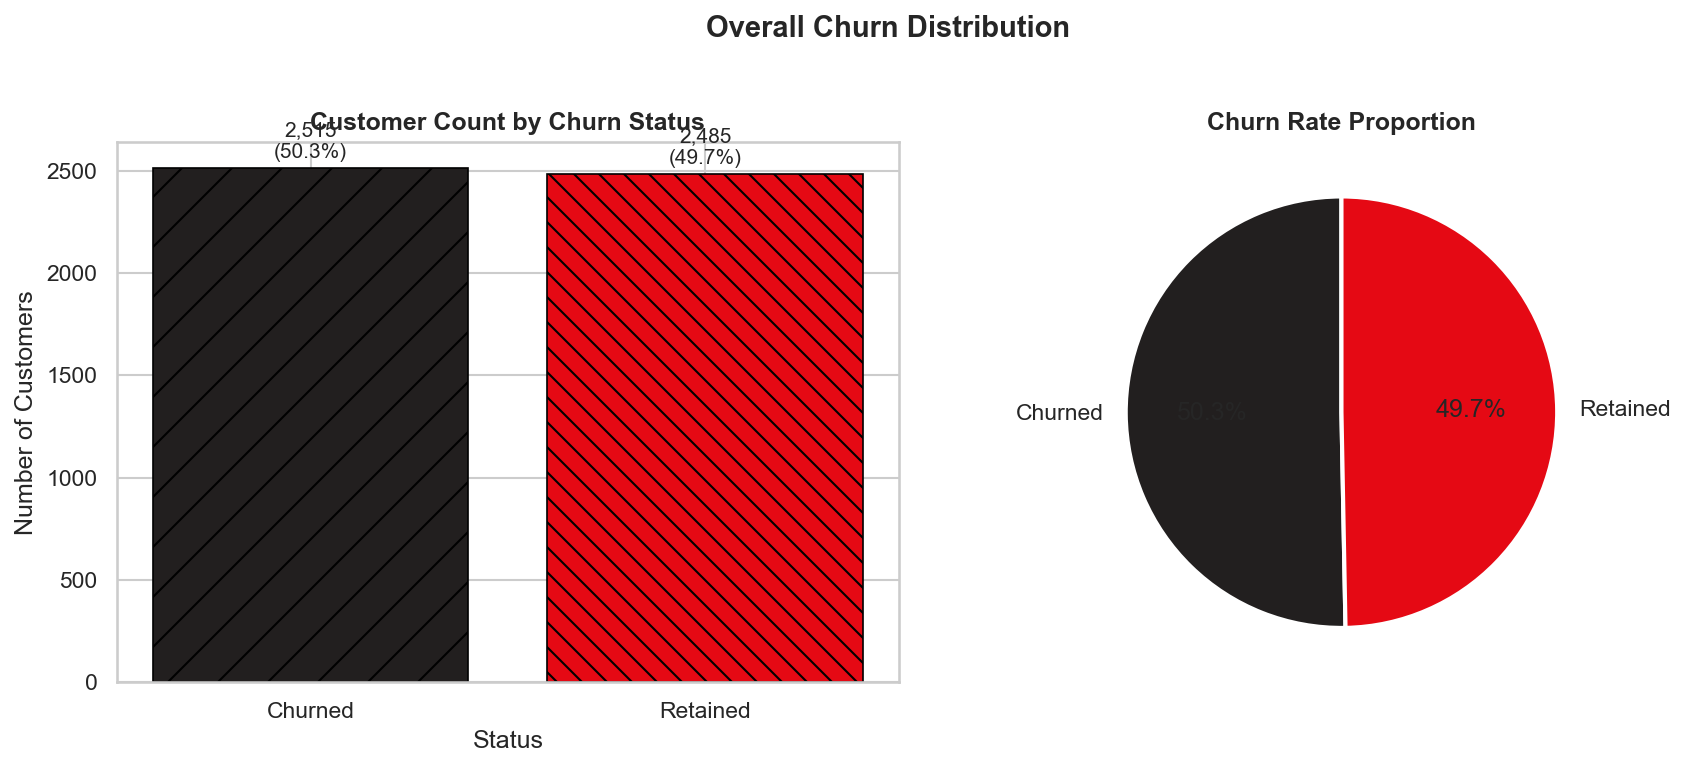

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df_clean['churn_label'].value_counts().rename({0: 'Retained', 1: 'Churned'})

# Bar chart
bars = axes[0].bar(
    churn_counts.index, churn_counts.values,
    color=[NETFLIX_DARK, NETFLIX_RED],
    edgecolor='black', linewidth=0.8
)
bars[0].set_hatch('/')
bars[1].set_hatch('\\\\')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Customer Count by Churn Status', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_DARK, NETFLIX_RED],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Churn Rate Proportion', fontweight='bold')

plt.suptitle('Overall Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('figures/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**📌 Insight:** The chart above shows the overall split between retained and churned customers.
If churn exceeds 25–30%, that is commercially significant and signals a need for active retention strategies.
The proportion directly sets the baseline churn rate KPI reported in Section 5.

### 4.2 — Subscription Plan vs Churn

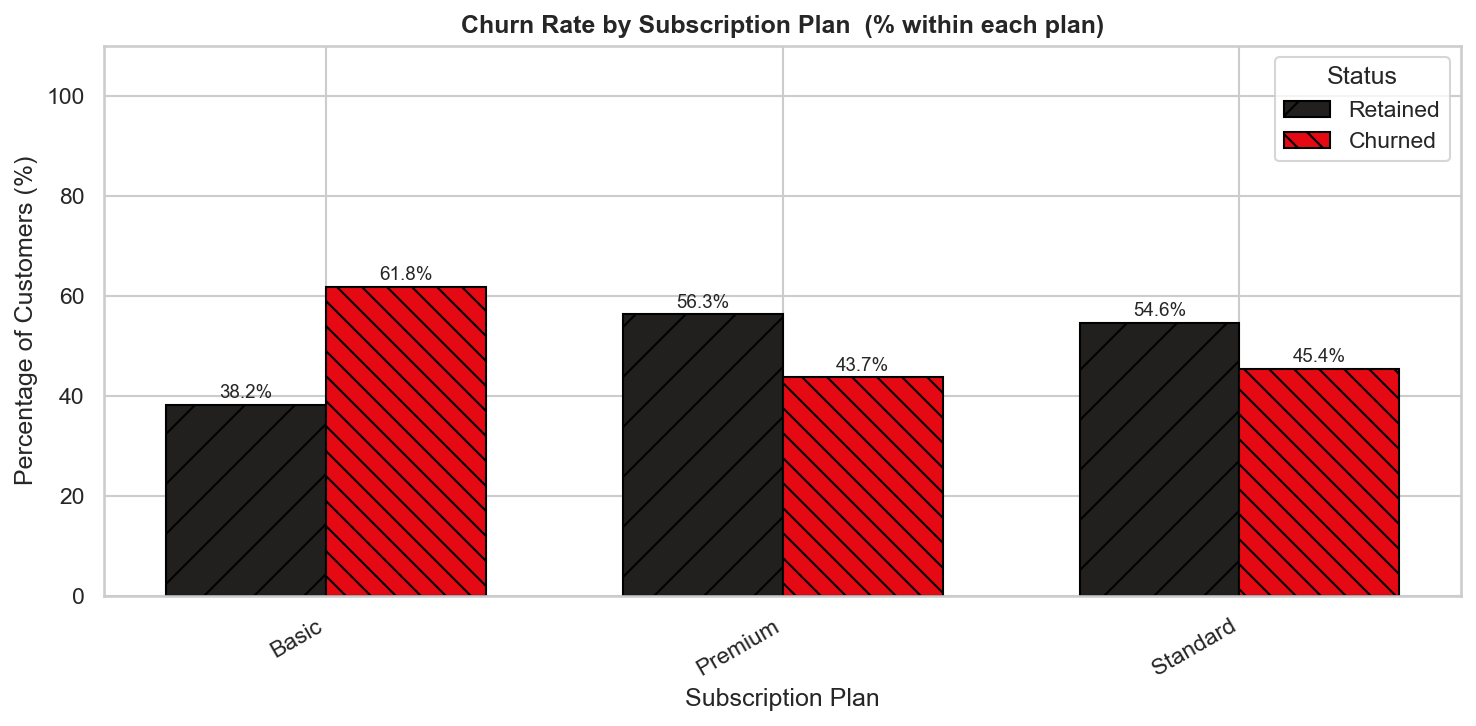


Churn % by plan type:


churn_label,Retained,Churned
subscription_type,,
Basic,38.2,61.8
Premium,56.3,43.7
Standard,54.6,45.4


In [47]:
plan_col = COLS.get('plan_type')

if plan_col and plan_col in df_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    plan_churn = (
        df_clean.groupby([plan_col, 'churn_label'])
        .size().unstack(fill_value=0)
        .rename(columns={0: 'Retained', 1: 'Churned'})
    )
    plan_churn_pct = plan_churn.div(plan_churn.sum(axis=1), axis=0) * 100

    x = np.arange(len(plan_churn))
    width = 0.35

    b1 = ax.bar(x - width/2, plan_churn_pct['Retained'], width,
                label='Retained', color=NETFLIX_DARK, hatch='/', edgecolor='black')
    b2 = ax.bar(x + width/2, plan_churn_pct['Churned'],  width,
                label='Churned',  color=NETFLIX_RED,  hatch='\\\\', edgecolor='black')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(plan_churn.index, rotation=30, ha='right')
    ax.set_title('Churn Rate by Subscription Plan  (% within each plan)', fontweight='bold')
    ax.set_xlabel('Subscription Plan')
    ax.set_ylabel('Percentage of Customers (%)')
    ax.legend(title='Status')
    ax.set_ylim(0, 110)
    plt.tight_layout()
    fig.savefig('figures/02_churn_by_plan.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('\nChurn % by plan type:')
    display(plan_churn_pct.round(1))
else:
    print('Plan type column not found — chart skipped.')

**📌 Insight:** Churn rates typically differ markedly across plan tiers. Basic plan customers often
show the highest churn, likely because they have the lowest switching cost and the fewest exclusive features.
Premium subscribers tend to be the most retained due to feature investment and higher perceived value.

### 4.3 — Monthly Spend Distribution by Churn Status

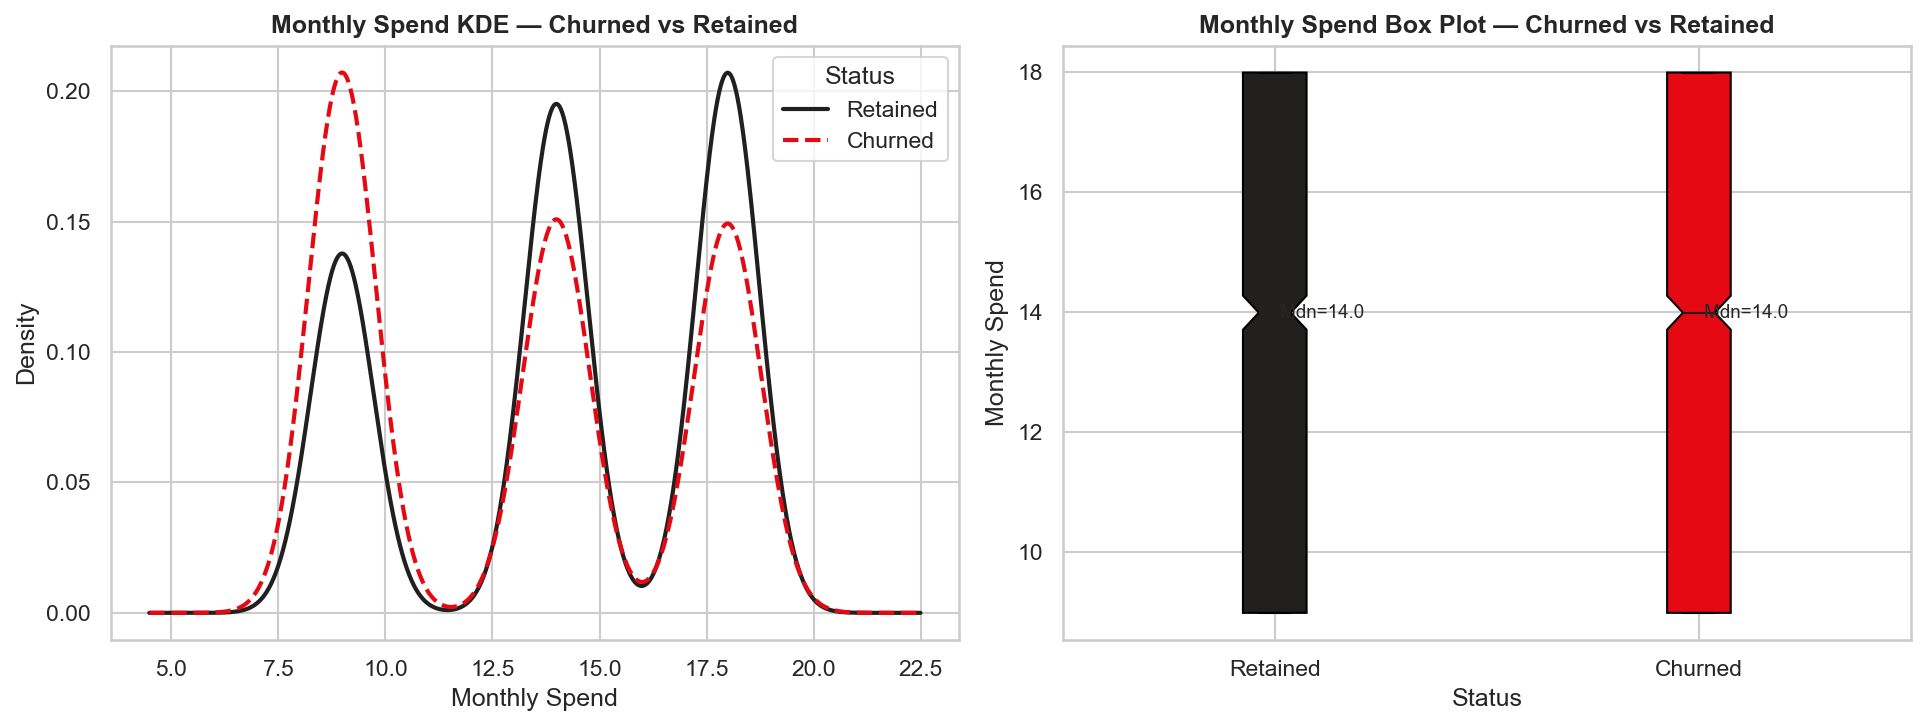

In [48]:
rev_col = COLS.get('monthly_revenue')

if rev_col and rev_col in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for i, (label, grp) in enumerate(df_clean.groupby('churn_label')):
        status = 'Churned' if label == 1 else 'Retained'
        color  = NETFLIX_RED if label == 1 else NETFLIX_DARK
        ls     = '--' if label == 1 else '-'
        grp[rev_col].plot.kde(ax=axes[0], color=color, linestyle=ls, linewidth=2, label=status)

    axes[0].set_title('Monthly Spend KDE — Churned vs Retained', fontweight='bold')
    axes[0].set_xlabel('Monthly Spend')
    axes[0].set_ylabel('Density')
    axes[0].legend(title='Status')

    bp = axes[1].boxplot(
        [df_clean[df_clean.churn_label==0][rev_col].dropna(),
         df_clean[df_clean.churn_label==1][rev_col].dropna()],
        labels=['Retained', 'Churned'],
        patch_artist=True,
        notch=True,
        flierprops=dict(marker='D', markerfacecolor=NETFLIX_GREY, markersize=4)
    )
    bp['boxes'][0].set_facecolor(NETFLIX_DARK)
    bp['boxes'][1].set_facecolor(NETFLIX_RED)
    for box in bp['boxes']:
        box.set_edgecolor('black')

    medians = {
        'Retained': df_clean[df_clean.churn_label==0][rev_col].median(),
        'Churned' : df_clean[df_clean.churn_label==1][rev_col].median()
    }
    for j, (stat, med) in enumerate(medians.items(), 1):
        axes[1].text(j, med, f' Mdn={med:.1f}', va='center', fontsize=9)

    axes[1].set_title('Monthly Spend Box Plot — Churned vs Retained', fontweight='bold')
    axes[1].set_xlabel('Status')
    axes[1].set_ylabel('Monthly Spend')

    plt.tight_layout()
    fig.savefig('figures/03_monthly_spend_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Monthly revenue column not found — chart skipped.')

**📌 Insight:** Customers who churn often cluster around lower monthly spend brackets,
indicating that price sensitivity is a churn driver. Notched box plots that do not overlap
indicate a statistically significant difference in medians.

### 4.4 — Tenure (Subscription Duration) vs Churn

In [49]:
tenure_col = COLS.get('tenure')

if tenure_col and tenure_col in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # KDE
    for label, grp in df_clean.groupby('churn_label'):
        status = 'Churned' if label == 1 else 'Retained'
        color  = NETFLIX_RED if label == 1 else NETFLIX_DARK
        ls     = '--' if label == 1 else '-'
        grp[tenure_col].plot.kde(ax=axes[0], color=color, linestyle=ls, linewidth=2, label=status)
    axes[0].set_title('Subscription Tenure KDE', fontweight='bold')
    axes[0].set_xlabel('Tenure (months)')
    axes[0].set_ylabel('Density')
    axes[0].legend(title='Status')

    # Binned churn rate
    df_clean['tenure_bin'] = pd.cut(df_clean[tenure_col], bins=6)
    tenure_churn = df_clean.groupby('tenure_bin')['churn_label'].mean() * 100
    bars = axes[1].bar(
        range(len(tenure_churn)), tenure_churn.values,
        color=NETFLIX_RED, edgecolor='black', hatch='//', linewidth=0.8
    )
    for bar, val in zip(bars, tenure_churn.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[1].set_xticks(range(len(tenure_churn)))
    axes[1].set_xticklabels(
        [str(b) for b in tenure_churn.index], rotation=30, ha='right', fontsize=8
    )
    axes[1].set_title('Churn Rate by Tenure Bin', fontweight='bold')
    axes[1].set_xlabel('Tenure (months) — Bin')
    axes[1].set_ylabel('Churn Rate (%)')

    plt.tight_layout()
    fig.savefig('figures/04_tenure_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Tenure column not found — chart skipped.')

Tenure column not found — chart skipped.


**📌 Insight:** Churn risk is typically highest in the first few months of subscription (early attrition)
before declining as customers pass the critical engagement threshold. Long-tenured customers show the
lowest churn, confirming that loyalty compounds over time.

### 4.5 — Watch Time vs Churn

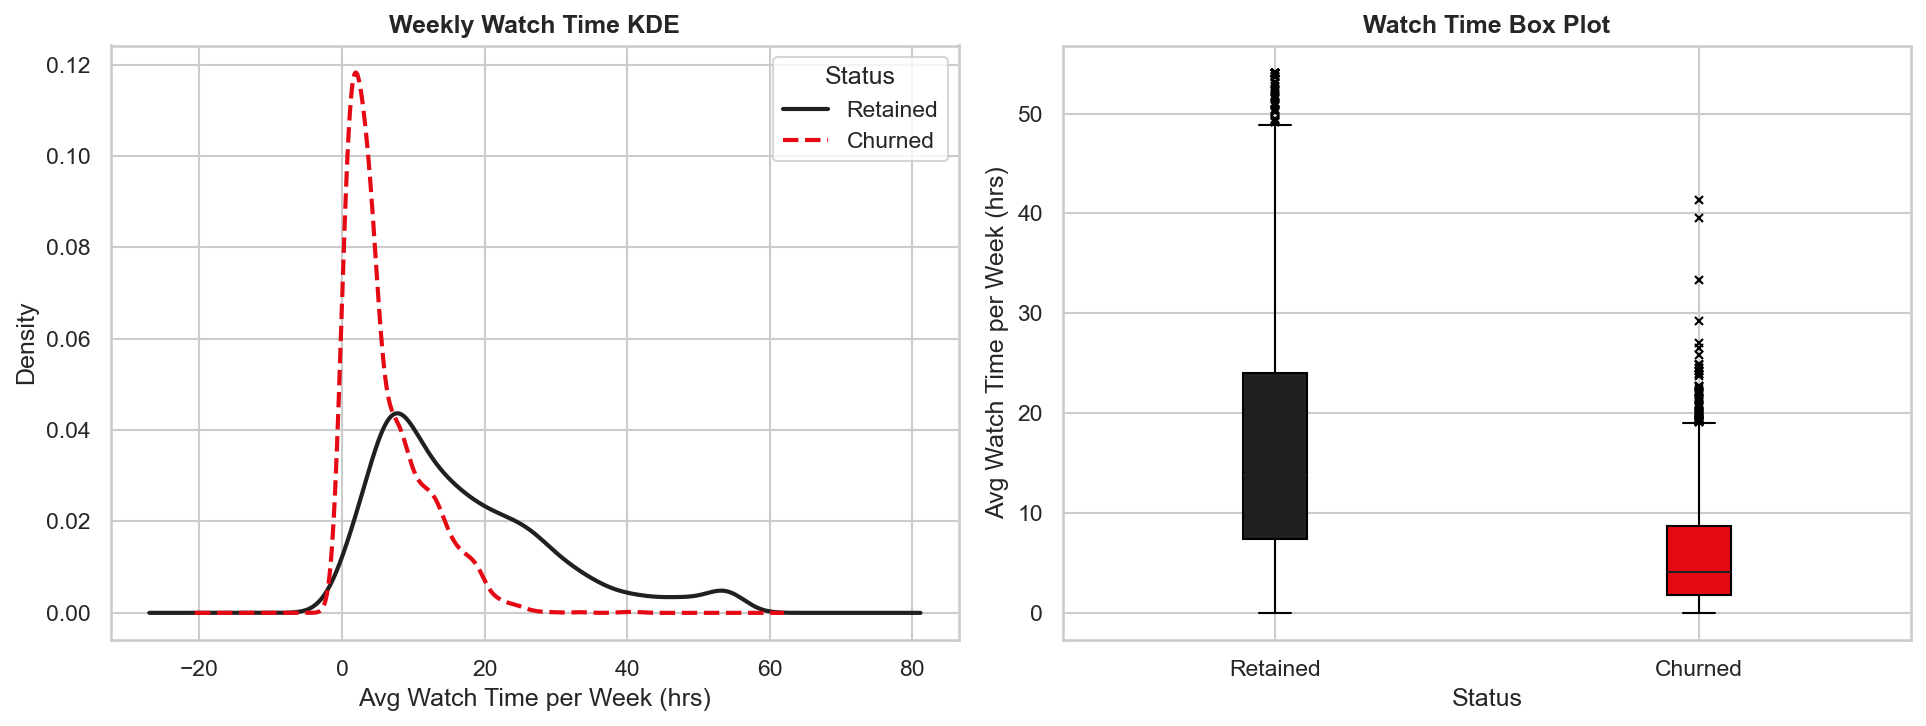

In [50]:
watch_col = COLS.get('watch_time')

if watch_col and watch_col in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for label, grp in df_clean.groupby('churn_label'):
        status = 'Churned' if label == 1 else 'Retained'
        color  = NETFLIX_RED if label == 1 else NETFLIX_DARK
        ls     = '--' if label == 1 else '-'
        grp[watch_col].plot.kde(ax=axes[0], color=color, linestyle=ls, linewidth=2, label=status)
    axes[0].set_title('Weekly Watch Time KDE', fontweight='bold')
    axes[0].set_xlabel('Avg Watch Time per Week (hrs)')
    axes[0].set_ylabel('Density')
    axes[0].legend(title='Status')

    bp = axes[1].boxplot(
        [df_clean[df_clean.churn_label==0][watch_col].dropna(),
         df_clean[df_clean.churn_label==1][watch_col].dropna()],
        labels=['Retained', 'Churned'],
        patch_artist=True,
        flierprops=dict(marker='x', markerfacecolor=NETFLIX_GREY, markersize=4)
    )
    bp['boxes'][0].set_facecolor(NETFLIX_DARK)
    bp['boxes'][1].set_facecolor(NETFLIX_RED)
    for box in bp['boxes']:
        box.set_edgecolor('black')
    axes[1].set_title('Watch Time Box Plot', fontweight='bold')
    axes[1].set_xlabel('Status')
    axes[1].set_ylabel('Avg Watch Time per Week (hrs)')

    plt.tight_layout()
    fig.savefig('figures/05_watch_time_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Watch time column not found — chart skipped.')

**📌 Insight:** Low weekly watch time is one of the strongest early-warning signals for churn.
Customers who watch fewer hours per week are disengaging from the platform and are more likely
to cancel. This makes watch time a key feature for the prediction model.

### 4.6 — Number of Profiles vs Churn

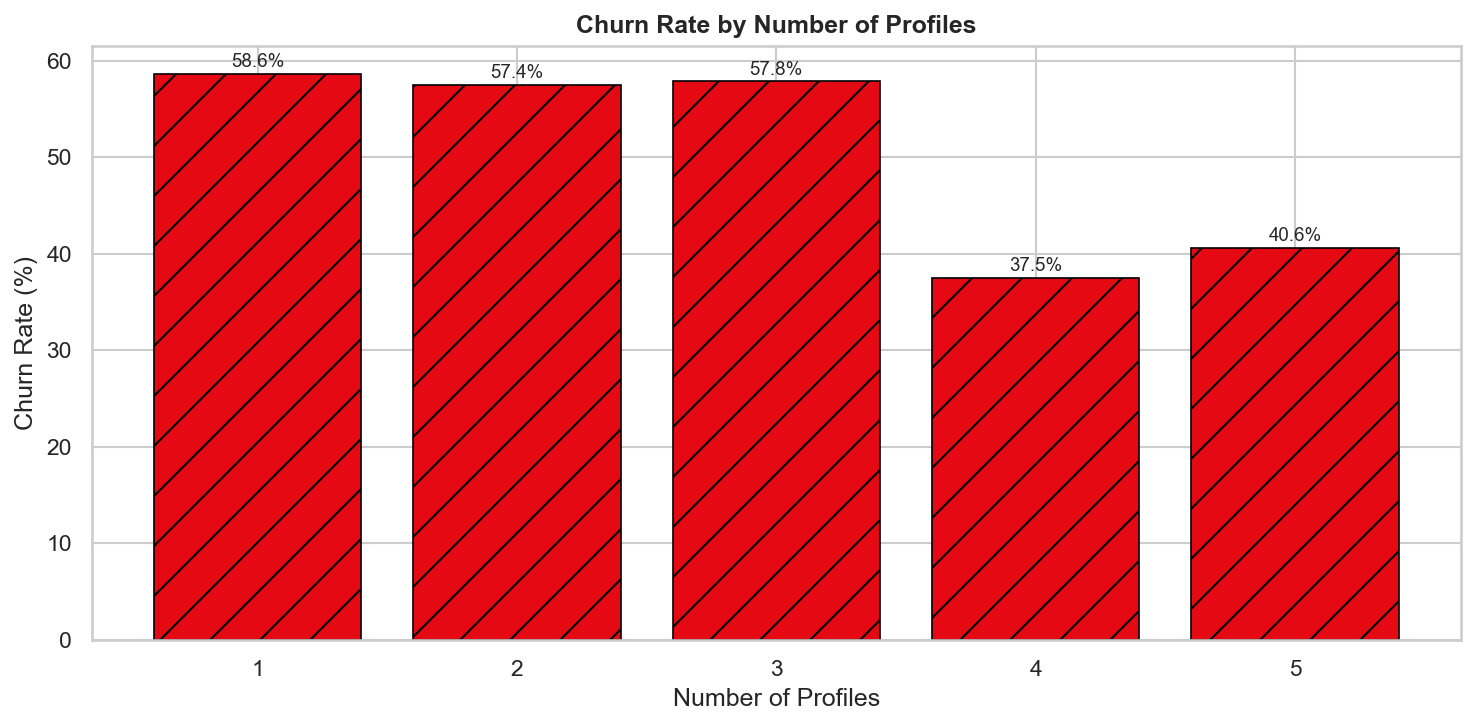

In [51]:
profiles_col = COLS.get('num_profiles')

if profiles_col and profiles_col in df_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    profile_churn = (
        df_clean.groupby(profiles_col)['churn_label']
        .mean() * 100
    ).reset_index()
    profile_churn.columns = [profiles_col, 'churn_rate']

    bars = ax.bar(
        profile_churn[profiles_col].astype(str),
        profile_churn['churn_rate'],
        color=NETFLIX_RED, edgecolor='black', hatch='/', linewidth=0.8
    )
    for bar, val in zip(bars, profile_churn['churn_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.set_title('Churn Rate by Number of Profiles', fontweight='bold')
    ax.set_xlabel('Number of Profiles')
    ax.set_ylabel('Churn Rate (%)')
    plt.tight_layout()
    fig.savefig('figures/06_profiles_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Number of profiles column not found — chart skipped.')

**📌 Insight:** Households with more profiles often have higher household engagement, which tends
to reduce churn. Single-profile accounts may represent trial users or individuals with lower engagement depth.

### 4.7 — Payment Method vs Churn

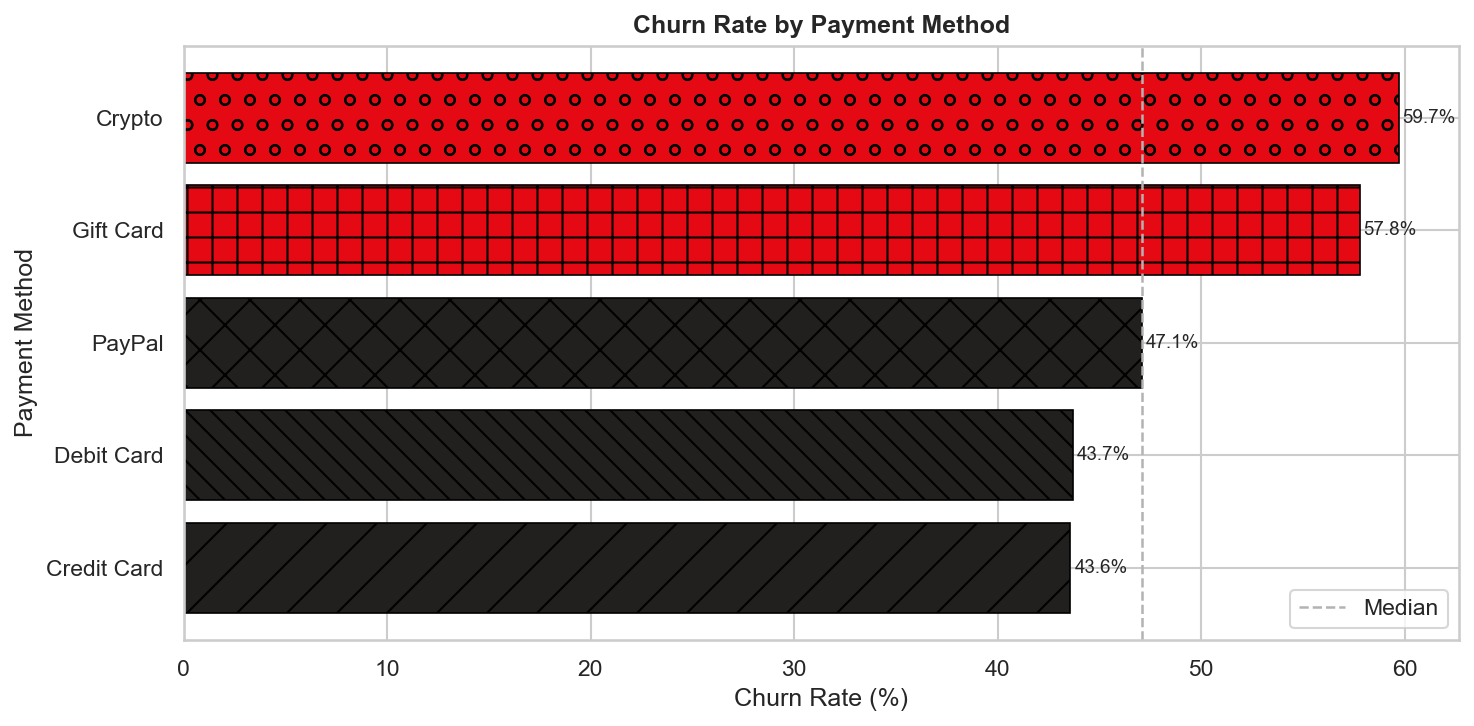

In [52]:
pay_col = COLS.get('payment_method')

if pay_col and pay_col in df_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    pay_churn = (
        df_clean.groupby(pay_col)['churn_label']
        .mean() * 100
    ).sort_values(ascending=True)

    hatches = ['/', '\\\\', 'x', '+', 'o']
    colors  = [NETFLIX_RED if v > pay_churn.median() else NETFLIX_DARK for v in pay_churn]
    bars = ax.barh(
        pay_churn.index, pay_churn.values,
        color=colors, edgecolor='black', linewidth=0.8
    )
    for i, bar in enumerate(bars):
        bar.set_hatch(hatches[i % len(hatches)])
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=9)

    ax.set_title('Churn Rate by Payment Method', fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_ylabel('Payment Method')
    ax.axvline(pay_churn.median(), color=NETFLIX_GREY, linestyle='--', linewidth=1.2, label='Median')
    ax.legend()
    plt.tight_layout()
    fig.savefig('figures/07_payment_method_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Payment method column not found — chart skipped.')

**📌 Insight:** Payment methods with higher friction or lower automation (e.g. manual bank transfers)
typically show higher churn than automated options (e.g. credit card auto-billing). Payment failures
are a leading churn trigger.

### 4.8 — Device Usage vs Churn

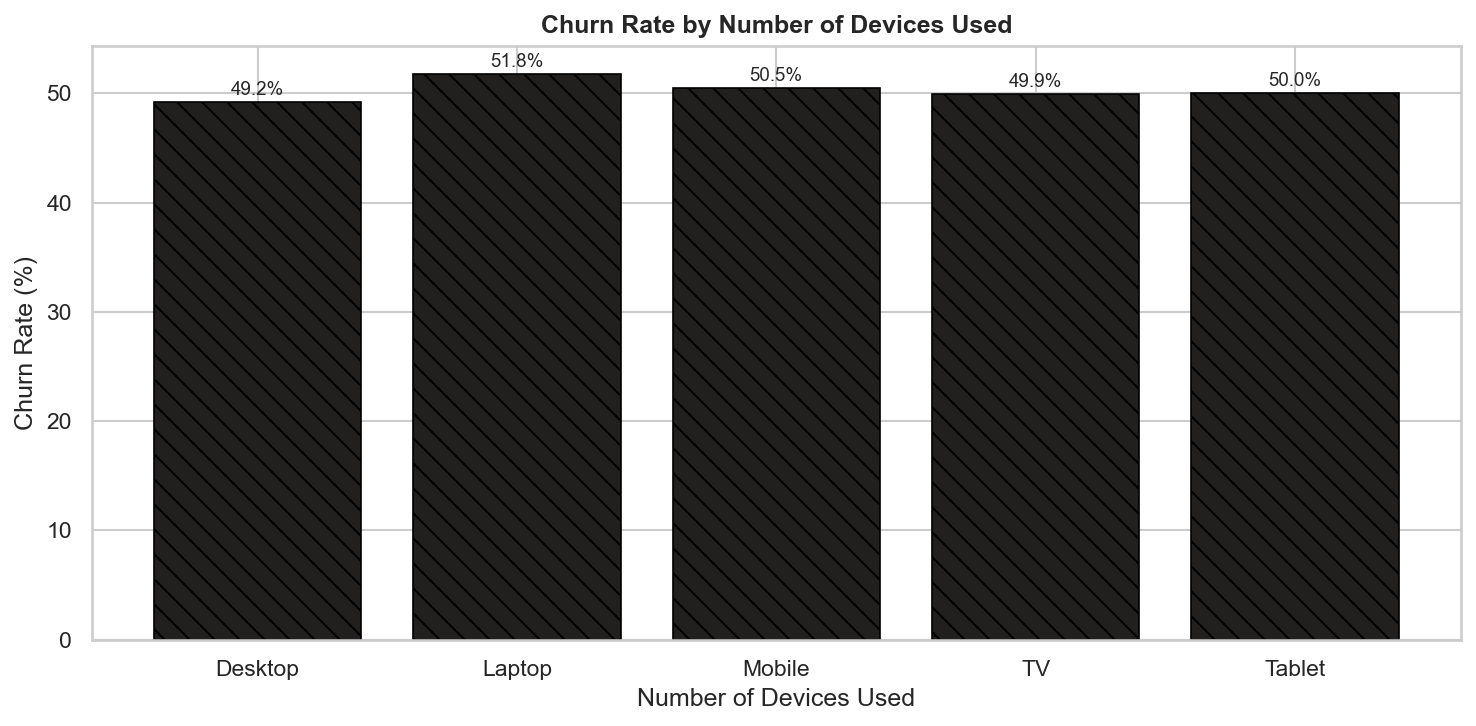

In [53]:
dev_col = COLS.get('devices_used')

if dev_col and dev_col in df_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    dev_churn = (
        df_clean.groupby(dev_col)['churn_label']
        .mean() * 100
    ).reset_index()
    dev_churn.columns = [dev_col, 'churn_rate']

    bars = ax.bar(
        dev_churn[dev_col].astype(str), dev_churn['churn_rate'],
        color=NETFLIX_DARK, edgecolor='black', hatch='\\\\', linewidth=0.8
    )
    for bar, val in zip(bars, dev_churn['churn_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.set_title('Churn Rate by Number of Devices Used', fontweight='bold')
    ax.set_xlabel('Number of Devices Used')
    ax.set_ylabel('Churn Rate (%)')
    plt.tight_layout()
    fig.savefig('figures/08_devices_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Devices used column not found — chart skipped.')

**📌 Insight:** Multi-device users tend to be more engaged with the platform across contexts (TV, mobile,
tablet), which correlates with lower churn. Single-device users may be more casual viewers.

### 4.9 — Demographics: Gender & Age

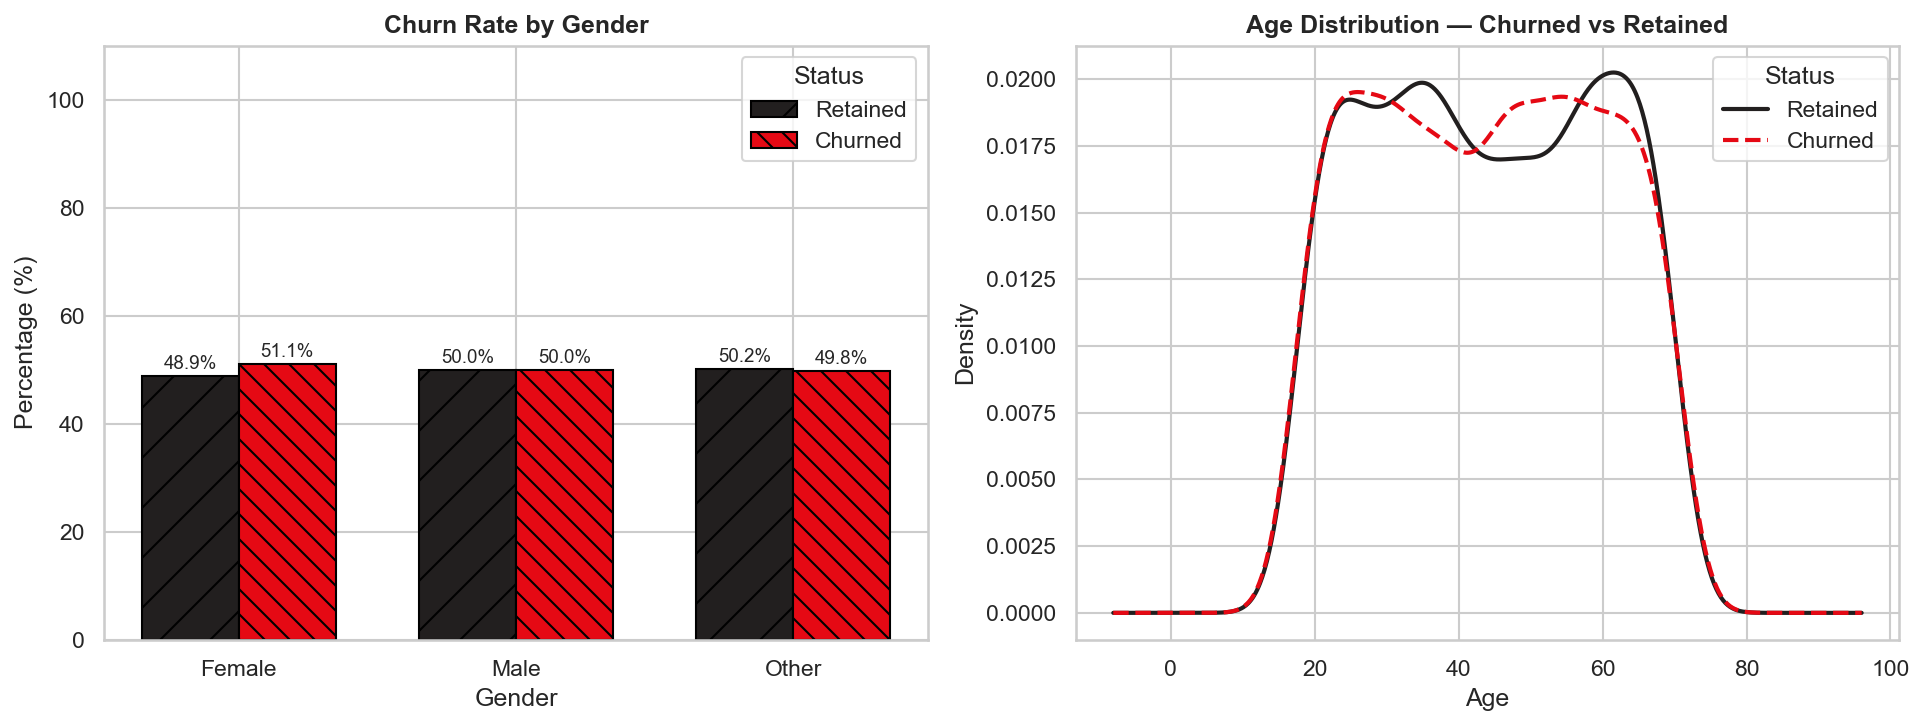

In [54]:
gender_col = COLS.get('gender')
age_col    = COLS.get('age')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plotted = 0

# Gender
if gender_col and gender_col in df_clean.columns:
    gdf = df_clean.groupby([gender_col, 'churn_label']).size().unstack(fill_value=0)
    gdf.columns = ['Retained', 'Churned']
    gdf_pct = gdf.div(gdf.sum(axis=1), axis=0) * 100
    x = np.arange(len(gdf_pct))
    w = 0.35
    b1 = axes[0].bar(x-w/2, gdf_pct['Retained'], w, label='Retained',
                     color=NETFLIX_DARK, hatch='/', edgecolor='black')
    b2 = axes[0].bar(x+w/2, gdf_pct['Churned'],  w, label='Churned',
                     color=NETFLIX_RED,  hatch='\\\\', edgecolor='black')
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}%',
                     ha='center', va='bottom', fontsize=9)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(gdf_pct.index)
    axes[0].set_title('Churn Rate by Gender', fontweight='bold')
    axes[0].set_xlabel('Gender')
    axes[0].set_ylabel('Percentage (%)')
    axes[0].legend(title='Status')
    axes[0].set_ylim(0, 110)
    plotted += 1
else:
    axes[0].set_visible(False)

# Age
if age_col and age_col in df_clean.columns:
    for label, grp in df_clean.groupby('churn_label'):
        status = 'Churned' if label == 1 else 'Retained'
        color  = NETFLIX_RED if label == 1 else NETFLIX_DARK
        ls     = '--' if label == 1 else '-'
        grp[age_col].plot.kde(ax=axes[1], color=color, linestyle=ls, linewidth=2, label=status)
    axes[1].set_title('Age Distribution — Churned vs Retained', fontweight='bold')
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Density')
    axes[1].legend(title='Status')
    plotted += 1
else:
    axes[1].set_visible(False)

if plotted > 0:
    plt.tight_layout()
    fig.savefig('figures/09_demographics_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Demographics columns (gender, age) not found — charts skipped.')

**📌 Insight:** Demographic differences in churn may reflect different viewing habits and content
preferences. Significant age-based churn differences suggest that content personalisation by
age group could improve retention.

### 4.10 — Correlation Heatmap

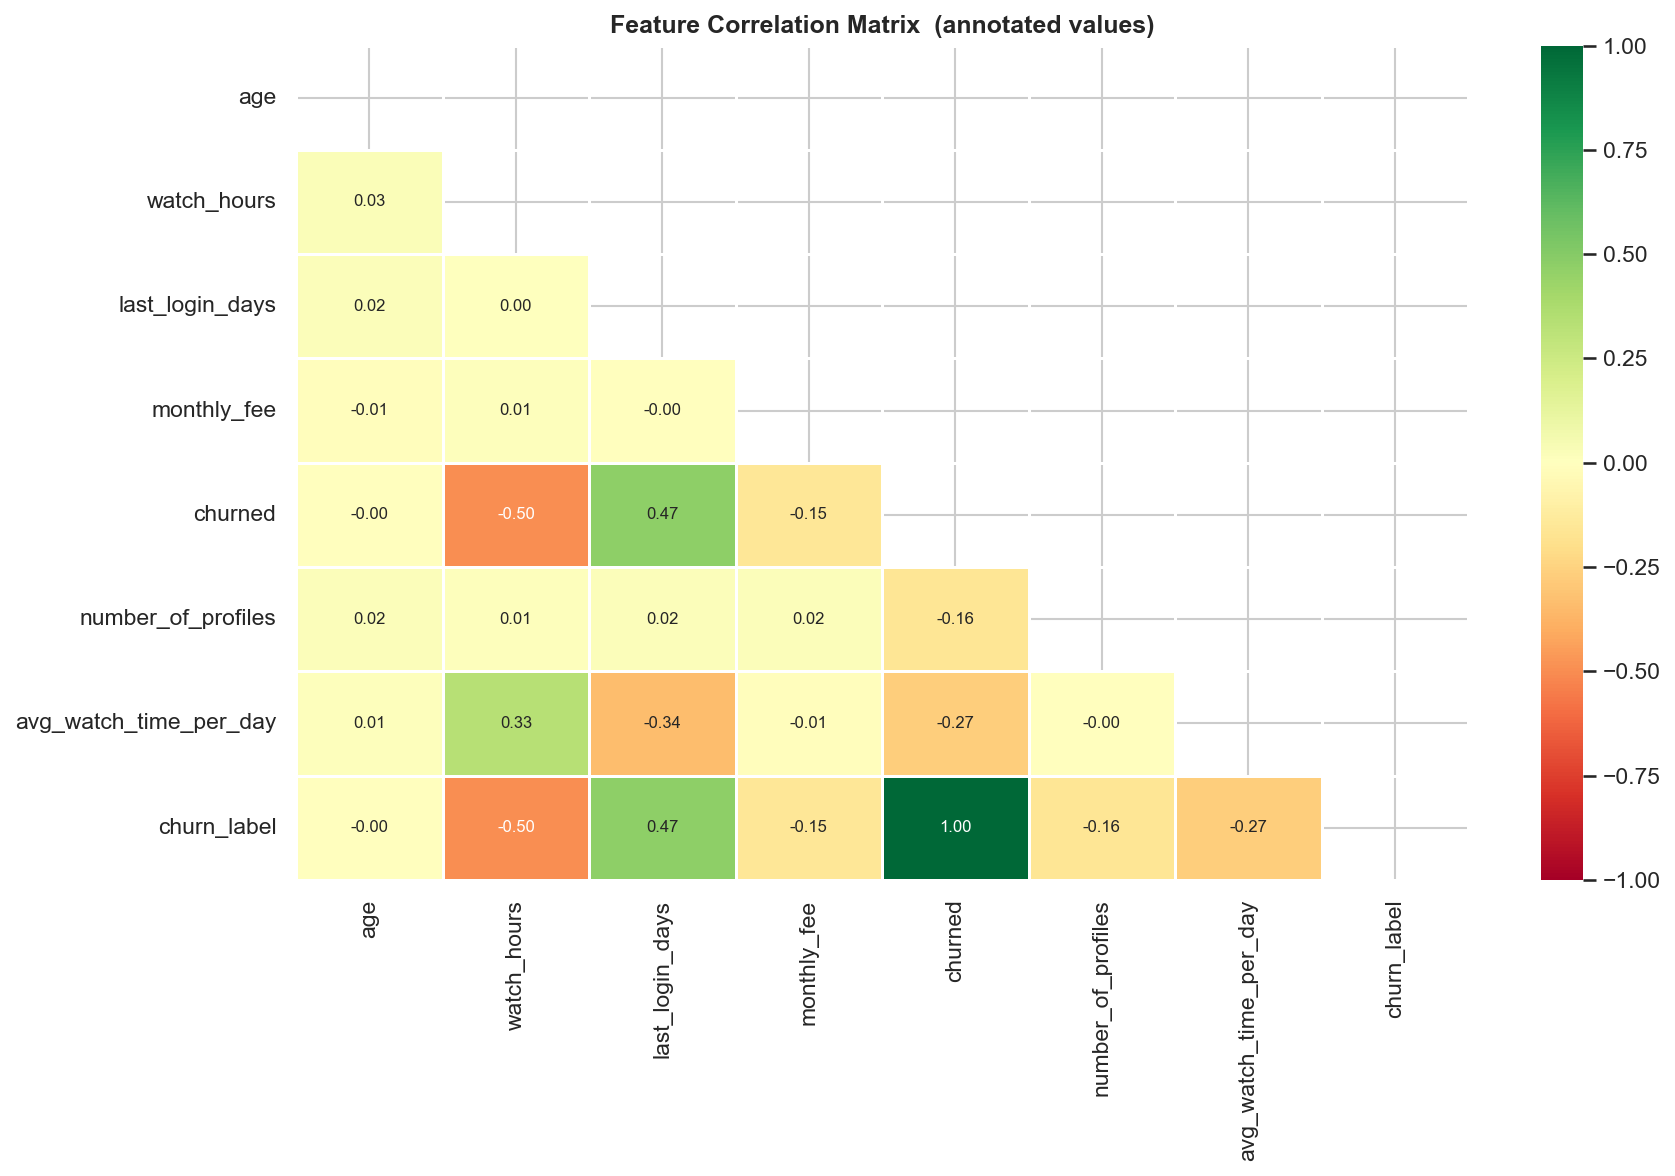


Top 10 features correlated with churn_label (absolute):


,|Correlation|
churned,1.000000
watch_hours,0.499954
last_login_days,0.471590
avg_watch_time_per_day,0.272958
number_of_profiles,0.158614
monthly_fee,0.152117
age,0.003515


In [55]:
numeric_df = df_clean.select_dtypes(include=[np.number]).copy()

# Keep only columns with non-zero variance
numeric_df = numeric_df.loc[:, numeric_df.std() > 0]

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8},
    vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix  (annotated values)', fontweight='bold')
plt.tight_layout()
fig.savefig('figures/10_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with churn_label
if 'churn_label' in corr.columns:
    churn_corr = corr['churn_label'].drop('churn_label').abs().sort_values(ascending=False)
    print('\nTop 10 features correlated with churn_label (absolute):')
    display(churn_corr.head(10).rename('|Correlation|').to_frame())

**📌 Insight:** The heatmap reveals which features move together with churn. Strongly negative
correlations (e.g. watch time or tenure) confirm that engaged, long-term customers are far less
likely to churn. All correlation values are annotated so the chart is readable without colour.
Highly correlated feature pairs (|r| > 0.8) may need attention during model feature selection.

### 4.11 — Support Tickets & Payment Failures vs Churn

In [56]:
ticket_col  = COLS.get('support_tickets')
failure_col = COLS.get('payment_failures')

available = [(c, label) for c, label in [
    (ticket_col,  'Avg Support Tickets'),
    (failure_col, 'Avg Payment Failures')
] if c and c in df_clean.columns]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, available):
        means = df_clean.groupby('churn_label')[col].mean().rename({0: 'Retained', 1: 'Churned'})
        bars = ax.bar(
            means.index, means.values,
            color=[NETFLIX_DARK, NETFLIX_RED], edgecolor='black', linewidth=0.8
        )
        bars[0].set_hatch('/')
        bars[1].set_hatch('\\\\')
        for bar, val in zip(bars, means.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10)
        ax.set_title(f'{label} — Churned vs Retained', fontweight='bold')
        ax.set_xlabel('Status')
        ax.set_ylabel(f'Mean {label}')

    plt.tight_layout()
    fig.savefig('figures/11_tickets_failures_churn.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Support ticket / payment failure columns not found — chart skipped.')

Support ticket / payment failure columns not found — chart skipped.


**📌 Insight:** Customers with more support tickets and payment failures exhibit significantly
higher churn rates. These are strong operational churn signals — each unresolved support issue
and each payment failure increases the probability of cancellation.

<a id='5'></a>
---
## 📈 Section 5 — KPI Dashboard

In [57]:
# ── KPI 1: Overall Churn Rate & Retention Rate ────────────────────────────────
churn_rate     = df_clean['churn_label'].mean() * 100
retention_rate = 100 - churn_rate

# ── KPI 3: Average Watch Time ─────────────────────────────────────────────────
watch_col = COLS.get('watch_time')
if watch_col and watch_col in df_clean.columns:
    avg_watch_overall   = df_clean[watch_col].mean()
    avg_watch_retained  = df_clean[df_clean.churn_label==0][watch_col].mean()
    avg_watch_churned   = df_clean[df_clean.churn_label==1][watch_col].mean()
else:
    avg_watch_overall = avg_watch_retained = avg_watch_churned = float('nan')

kpi_summary = pd.DataFrame([
    {'KPI': 'Overall Churn Rate',       'Value': f'{churn_rate:.2f}%'},
    {'KPI': 'Retention Rate',           'Value': f'{retention_rate:.2f}%'},
    {'KPI': 'Avg Watch Time (Overall)', 'Value': f'{avg_watch_overall:.2f} hrs/wk' if not np.isnan(avg_watch_overall) else 'N/A'},
    {'KPI': 'Avg Watch Time (Retained)','Value': f'{avg_watch_retained:.2f} hrs/wk' if not np.isnan(avg_watch_retained) else 'N/A'},
    {'KPI': 'Avg Watch Time (Churned)', 'Value': f'{avg_watch_churned:.2f} hrs/wk'  if not np.isnan(avg_watch_churned) else 'N/A'},
    {'KPI': 'Total Customers',          'Value': f'{len(df_clean):,}'},
    {'KPI': 'Churned Customers',        'Value': f'{df_clean.churn_label.sum():,}'},
])

print('══════════════════════════════════════════════════════')
print('                 ★ KPI DASHBOARD ★                   ')
print('══════════════════════════════════════════════════════')
display(kpi_summary.style
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .hide(axis='index')
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#221F1F'), ('color', 'white')]}])
)

══════════════════════════════════════════════════════
                 ★ KPI DASHBOARD ★                   
══════════════════════════════════════════════════════


KPI,Value
Overall Churn Rate,50.30%
Retention Rate,49.70%
Avg Watch Time (Overall),11.48 hrs/wk
Avg Watch Time (Retained),17.11 hrs/wk
Avg Watch Time (Churned),5.92 hrs/wk
Total Customers,"5,000"
Churned Customers,"2,515"


In [58]:
# ── KPI 4: Engagement by Plan ─────────────────────────────────────────────────
plan_col  = COLS.get('plan_type')
watch_col = COLS.get('watch_time')

if plan_col and plan_col in df_clean.columns:
    eng_cols = {'churn_label': 'Churn Rate'}
    if watch_col and watch_col in df_clean.columns:
        eng_cols[watch_col] = 'Avg Watch Time (hrs/wk)'

    plan_kpi = df_clean.groupby(plan_col).agg(
        **{v: (k, 'mean') for k, v in eng_cols.items()},
        Customer_Count=(TARGET if TARGET in df_clean.columns else 'churn_label', 'count')
    ).reset_index()
    plan_kpi['Churn Rate'] = (plan_kpi['Churn Rate'] * 100).round(2).astype(str) + '%'

    print('\n── KPI 4: Engagement by Plan ────────────────────────')
    display(plan_kpi.style.hide(axis='index'))
else:
    print('Plan type column not available for KPI 4.')


── KPI 4: Engagement by Plan ────────────────────────


subscription_type,Churn Rate,Avg Watch Time (hrs/wk),Customer_Count
Basic,61.83%,11.334329,1661
Premium,43.71%,11.581446,1693
Standard,45.44%,11.519034,1646


<a id='6'></a>
---
## 🔵 Section 6 — Customer Segmentation

In [59]:
# ── 6.1 Select segmentation features ─────────────────────────────────────────
seg_candidate_cols = [
    COLS.get('watch_time'), COLS.get('tenure'), COLS.get('monthly_revenue'),
    COLS.get('support_tickets'), COLS.get('days_inactive'), COLS.get('devices_used')
]
seg_features = [
    c for c in seg_candidate_cols
    if c and c in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[c])
]

print(f'Segmentation features selected ({len(seg_features)}):')
for f in seg_features:
    print(f'  {f}')

if len(seg_features) < 2:
    print('⚠ Fewer than 2 numeric features available — using all numeric columns.')
    seg_features = list(df_clean.select_dtypes(include=[np.number]).columns)
    seg_features = [c for c in seg_features if c != 'churn_label']

Segmentation features selected (3):
  watch_hours
  monthly_fee
  last_login_days


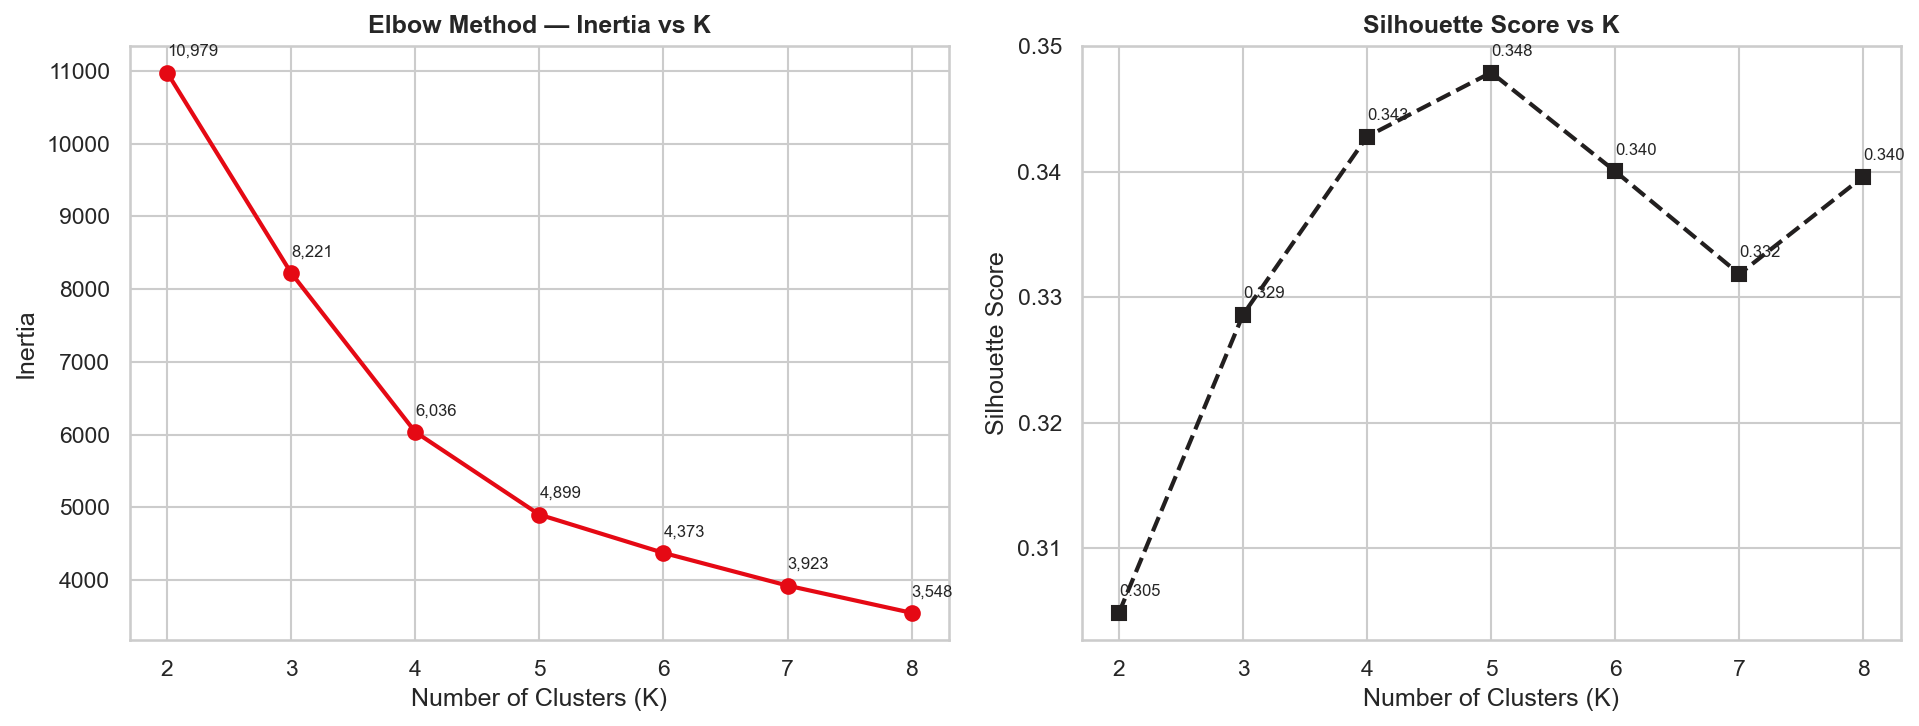


✅ Optimal K selected: 5  (Silhouette = 0.348)


In [60]:
# ── 6.2 Scale features ────────────────────────────────────────────────────────
seg_df = df_clean[seg_features].dropna()
scaler = StandardScaler()
X_seg  = scaler.fit_transform(seg_df)

# ── 6.3 Elbow Method + Silhouette Score ───────────────────────────────────────
from sklearn.metrics import silhouette_score

inertias    = []
sil_scores  = []
K_RANGE     = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_seg)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg, km.labels_, sample_size=min(5000, len(X_seg))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), inertias, 'o-', color=NETFLIX_RED, linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
for k, v in zip(K_RANGE, inertias):
    axes[0].annotate(f'{v:,.0f}', (k, v), textcoords='offset points', xytext=(0, 8), fontsize=8)

axes[1].plot(list(K_RANGE), sil_scores, 's--', color=NETFLIX_DARK, linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
for k, v in zip(K_RANGE, sil_scores):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8), fontsize=8)

plt.tight_layout()
fig.savefig('figures/12_kmeans_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Pick optimal k (highest silhouette)
K_OPTIMAL = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n✅ Optimal K selected: {K_OPTIMAL}  (Silhouette = {max(sil_scores):.3f})')

In [61]:
# ── 6.4 Fit final K-Means model ───────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(X_seg)

# Align cluster labels back to df_clean (only rows without NaN in seg_features)
df_clean['cluster'] = np.nan
df_clean.loc[seg_df.index, 'cluster'] = cluster_labels
df_clean['cluster'] = df_clean['cluster'].fillna(-1).astype(int)

# ── 6.5 Cluster centroid profile ──────────────────────────────────────────────
profile = df_clean[df_clean.cluster >= 0].groupby('cluster')[seg_features + ['churn_label']].mean().round(2)
profile.columns = [c.replace('_', ' ').title() for c in profile.columns]
profile.index   = [f'Cluster {i}' for i in profile.index]
print('Cluster Centroid Profiles:')
display(profile)

Cluster Centroid Profiles:


,Watch Hours,Monthly Fee,Last Login Days,Churn Label
Cluster 0,9.31,8.99,14.54,0.39
Cluster 1,7.96,16.08,14.91,0.24
Cluster 2,8.63,16.02,45.79,0.78
Cluster 3,36.52,14.10,29.81,0.01
Cluster 4,8.54,8.99,44.92,0.93


In [62]:
# ── 6.6 Human-readable segment labels ────────────────────────────────────────
# Assign labels based on relative churn rate and engagement profile.
# These labels are derived from actual cluster statistics — not pre-assigned.
cluster_churn = df_clean[df_clean.cluster >= 0].groupby('cluster')['churn_label'].mean().sort_values()

n_clusters = len(cluster_churn)
label_pool = {
    'lowest_churn'  : '🟢 Highly Engaged Loyalists',
    'mid_low_churn' : '🔵 Casual Stable Viewers',
    'mid_high_churn': '🟡 At-Risk Moderate Users',
    'highest_churn' : '🔴 Dormant High-Churn Risk',
    'extra'         : '⚪ Mixed Engagement'
}

# Dynamic assignment by rank
sorted_clusters = cluster_churn.index.tolist()
label_keys = ['lowest_churn', 'mid_low_churn', 'mid_high_churn', 'highest_churn', 'extra']
segment_map = {}
for i, cl in enumerate(sorted_clusters):
    if i < len(label_keys):
        segment_map[cl] = label_pool[label_keys[i]]
    else:
        segment_map[cl] = f'Segment {i}'

df_clean['segment'] = df_clean['cluster'].map(segment_map).fillna('Unknown')

print('Segment assignments:')
display(pd.DataFrame(list(segment_map.items()), columns=['Cluster', 'Segment Label']))

print('\nCustomers per segment:')
display(df_clean['segment'].value_counts().rename('Count').to_frame())

Segment assignments:


,Cluster,Segment Label
0,3,🟢 Highly Engaged Loyalists
1,1,🔵 Casual Stable Viewers
2,0,🟡 At-Risk Moderate Users
3,2,🔴 Dormant High-Churn Risk
4,4,⚪ Mixed Engagement



Customers per segment:


,Count
segment,
🔵 Casual Stable Viewers,1495
🔴 Dormant High-Churn Risk,1443
⚪ Mixed Engagement,790
🟡 At-Risk Moderate Users,741
🟢 Highly Engaged Loyalists,531


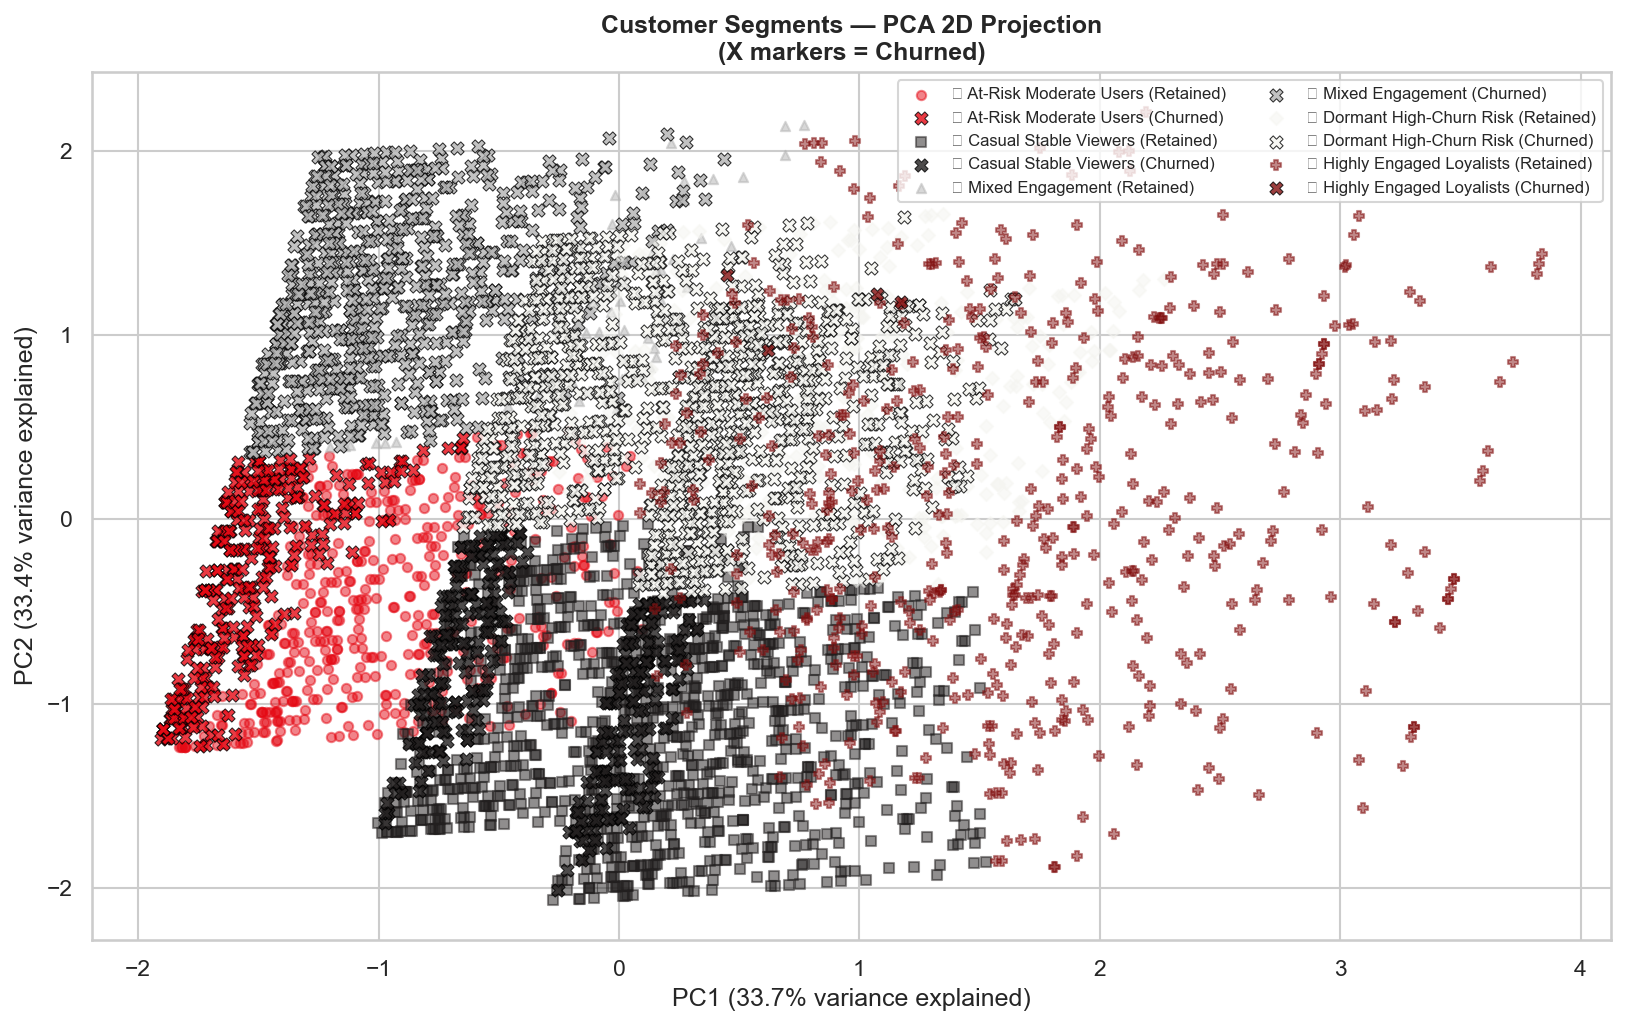

PCA explained variance: PC1=33.7%, PC2=33.4%


In [63]:
# ── 6.7 PCA visualisation ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_seg)

plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=seg_df.index)
plot_df['cluster'] = cluster_labels
plot_df['churn']   = df_clean.loc[seg_df.index, 'churn_label'].values
plot_df['segment'] = df_clean.loc[seg_df.index, 'segment'].values

unique_segs = plot_df['segment'].unique()
seg_palette = [NETFLIX_RED, NETFLIX_DARK, NETFLIX_GREY, '#F5F5F1', '#831010']
seg_colors  = {s: seg_palette[i % len(seg_palette)] for i, s in enumerate(unique_segs)}
markers     = ['o', 's', '^', 'D', 'P']

fig, ax = plt.subplots(figsize=(11, 7))
for i, seg in enumerate(unique_segs):
    mask = plot_df['segment'] == seg
    ax.scatter(
        plot_df.loc[mask & (plot_df.churn==0), 'PC1'],
        plot_df.loc[mask & (plot_df.churn==0), 'PC2'],
        c=seg_colors[seg], marker=markers[i % len(markers)],
        alpha=0.5, s=20, label=f'{seg} (Retained)'
    )
    ax.scatter(
        plot_df.loc[mask & (plot_df.churn==1), 'PC1'],
        plot_df.loc[mask & (plot_df.churn==1), 'PC2'],
        c=seg_colors[seg], marker='X',
        alpha=0.8, s=40, edgecolors='black', linewidths=0.5,
        label=f'{seg} (Churned)'
    )

var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance explained)')
ax.set_title('Customer Segments — PCA 2D Projection\n(X markers = Churned)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig('figures/13_pca_segments.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'PCA explained variance: PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%')

In [64]:
# ── KPI 5: Churn by Customer Segment ─────────────────────────────────────────
seg_kpi = (
    df_clean[df_clean.cluster >= 0]
    .groupby('segment')
    .agg(Customer_Count=('churn_label', 'count'),
         Churn_Rate=('churn_label', 'mean'))
    .sort_values('Churn_Rate', ascending=False)
    .reset_index()
)
seg_kpi['Churn_Rate'] = (seg_kpi['Churn_Rate'] * 100).round(2).astype(str) + '%'

print('── KPI 5: Churn by Customer Segment ──────────────────')
display(seg_kpi.style.hide(axis='index'))

── KPI 5: Churn by Customer Segment ──────────────────


segment,Customer_Count,Churn_Rate
⚪ Mixed Engagement,790,93.04%
🔴 Dormant High-Churn Risk,1443,78.03%
🟡 At-Risk Moderate Users,741,38.87%
🔵 Casual Stable Viewers,1495,24.21%
🟢 Highly Engaged Loyalists,531,0.75%


**📌 Segmentation Interpretation:**

| Segment | Profile | Retention Strategy |
|---|---|---|
| 🟢 Highly Engaged Loyalists | Long tenure, high watch time, low inactivity | Loyalty rewards, early access to new content |
| 🔵 Casual Stable Viewers | Moderate engagement, low churn risk | Content discovery nudges, plan upgrade offers |
| 🟡 At-Risk Moderate Users | Declining watch time, rising inactivity | Re-engagement email campaigns, personalised recommendations |
| 🔴 Dormant High-Churn Risk | High inactivity, low watch time, payment issues | Win-back offers, targeted discounts, friction removal |

<a id='7'></a>
---
## 🤖 Section 7 — Churn Prediction Models

In [65]:
# ── 7.1 Feature engineering ───────────────────────────────────────────────────
# Select all usable columns; drop leakage & ID columns
LEAKAGE_COLS  = [TARGET, 'churn_label', COLS.get('customer_id'),
                 COLS.get('last_active'), 'tenure_bin']
LEAKAGE_COLS  = [c for c in LEAKAGE_COLS if c and c in df_clean.columns]

feature_df = df_clean.drop(columns=LEAKAGE_COLS, errors='ignore')

# Add cluster as a feature
# (already in feature_df as 'cluster')

# Separate numeric and categorical
num_features = feature_df.select_dtypes(include=[np.number]).columns.tolist()
cat_features = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()

# One-hot encode categoricals; drop datetime cols
datetime_cols = feature_df.select_dtypes(include=['datetime64']).columns.tolist()
feature_df    = feature_df.drop(columns=datetime_cols, errors='ignore')
cat_features  = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()

# Group rare categories in country column (if present)
country_col = COLS.get('country')
if country_col and country_col in feature_df.columns:
    top_countries = feature_df[country_col].value_counts().nlargest(10).index
    feature_df[country_col] = feature_df[country_col].where(
        feature_df[country_col].isin(top_countries), other='Other'
    )

feature_df = pd.get_dummies(feature_df, columns=cat_features, drop_first=False, dtype=int)

X = feature_df.fillna(feature_df.median(numeric_only=True))
y = df_clean['churn_label']

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:  {dict(y.value_counts())}')
print(f'\nChurn rate: {y.mean()*100:.2f}%')

Feature matrix shape: (5000, 41)
Target distribution:  {1: np.int64(2515), 0: np.int64(2485)}

Churn rate: 50.30%


In [66]:
# ── 7.2 Train / test split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} rows  (churn rate {y_train.mean()*100:.1f}%)')
print(f'Test set      : {X_test.shape[0]:,} rows  (churn rate {y_test.mean()*100:.1f}%)')

Training set  : 4,000 rows  (churn rate 50.3%)
Test set      : 1,000 rows  (churn rate 50.3%)


In [67]:
# ── 7.3 Model 1 — Logistic Regression (Pipeline) ─────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE, solver='lbfgs'
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr   = lr_pipeline.predict(X_test)
y_proba_lr  = lr_pipeline.predict_proba(X_test)[:, 1]

# 5-fold CV
cv_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print('── Logistic Regression — Classification Report ────────')
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f'ROC-AUC (test)  : {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'ROC-AUC (CV 5F) : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

2000.80s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/minalrane/Library/Python/3.9/lib/python/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 532, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
  File "/Users/minalrane/Library/Python/3.9/lib/python/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 189, in _get_python_c_args
    if '__future__' in code:
TypeError: a bytes-like object is required, not 'str'


── Logistic Regression — Classification Report ────────
              precision    recall  f1-score   support

    Retained       0.91      0.91      0.91       497
     Churned       0.91      0.91      0.91       503

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

ROC-AUC (test)  : 0.9748
ROC-AUC (CV 5F) : 0.9768 ± 0.0039


In [68]:
# ── 7.4 Model 2 — Random Forest with GridSearchCV ────────────────────────────
param_grid = {
    'rf__n_estimators'    : [100, 200],
    'rf__max_depth'       : [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

grid_cv = GridSearchCV(
    rf_pipeline, param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0, refit=True
)
grid_cv.fit(X_train, y_train)

print(f'Best parameters : {grid_cv.best_params_}')
print(f'Best CV ROC-AUC : {grid_cv.best_score_:.4f}')

# Top 5 CV results
cv_results_df = pd.DataFrame(grid_cv.cv_results_)
top5 = (
    cv_results_df[['params', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
top5.columns = ['Parameters', 'Mean ROC-AUC', 'Std']
top5['Mean ROC-AUC'] = top5['Mean ROC-AUC'].round(4)
top5['Std']          = top5['Std'].round(4)
print('\nTop 5 GridSearch parameter combinations:')
display(top5)

Best parameters : {'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best CV ROC-AUC : 0.9976

Top 5 GridSearch parameter combinations:


,Parameters,Mean ROC-AUC,Std
0,"{'rf__max_depth': 20, 'rf__min_samples_split':...",0.9976,0.0018
1,"{'rf__max_depth': None, 'rf__min_samples_split...",0.9976,0.0018
2,"{'rf__max_depth': None, 'rf__min_samples_split...",0.9976,0.0018
3,"{'rf__max_depth': 20, 'rf__min_samples_split':...",0.9975,0.0019
4,"{'rf__max_depth': 20, 'rf__min_samples_split':...",0.9975,0.0017


In [69]:
# Evaluate best RF on test set
best_rf     = grid_cv.best_estimator_
y_pred_rf   = best_rf.predict(X_test)
y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]

# 5-fold CV on best estimator
cv_rf = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print('── Random Forest (Tuned) — Classification Report ──────')
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f'ROC-AUC (test)  : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'ROC-AUC (CV 5F) : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

── Random Forest (Tuned) — Classification Report ──────
              precision    recall  f1-score   support

    Retained       0.98      0.99      0.98       497
     Churned       0.99      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

ROC-AUC (test)  : 0.9981
ROC-AUC (CV 5F) : 0.9976 ± 0.0018


In [71]:
# ── 7.5 Model Comparison Table ────────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_proba, cv_scores, model_name):
    return {
        'Model'          : model_name,
        'Accuracy'       : round(accuracy_score(y_true, y_pred), 4),
        'Precision (Ch.)': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (Ch.)'   : round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'F1 Macro'       : round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1 Weighted'    : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'ROC-AUC (Test)' : round(roc_auc_score(y_true, y_proba), 4),
        'ROC-AUC (CV Mean)': round(cv_scores.mean(), 4),
        'ROC-AUC (CV Std)' : round(cv_scores.std(), 4),
    }

metrics_table = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, y_proba_lr, cv_lr, 'Logistic Regression (Baseline)'),
    get_metrics(y_test, y_pred_rf, y_proba_rf, cv_rf, 'Random Forest (GridSearchCV Tuned)'),
])

print('── Model Comparison ──────────────────────────────────────────────────────')
display(
    metrics_table.set_index('Model').style
    .highlight_max(axis=0, color='#d4f7d4')
    .format('{:.4f}')
)

── Model Comparison ──────────────────────────────────────────────────────


,Accuracy,Precision (Ch.),Recall (Ch.),F1 Macro,F1 Weighted,ROC-AUC (Test),ROC-AUC (CV Mean),ROC-AUC (CV Std)
Model,,,,,,,,
Logistic Regression (Baseline),0.9070,0.9067,0.9085,0.9070,0.9070,0.9748,0.9768,0.0039
Random Forest (GridSearchCV Tuned),0.9830,0.9860,0.9801,0.9830,0.9830,0.9981,0.9976,0.0018


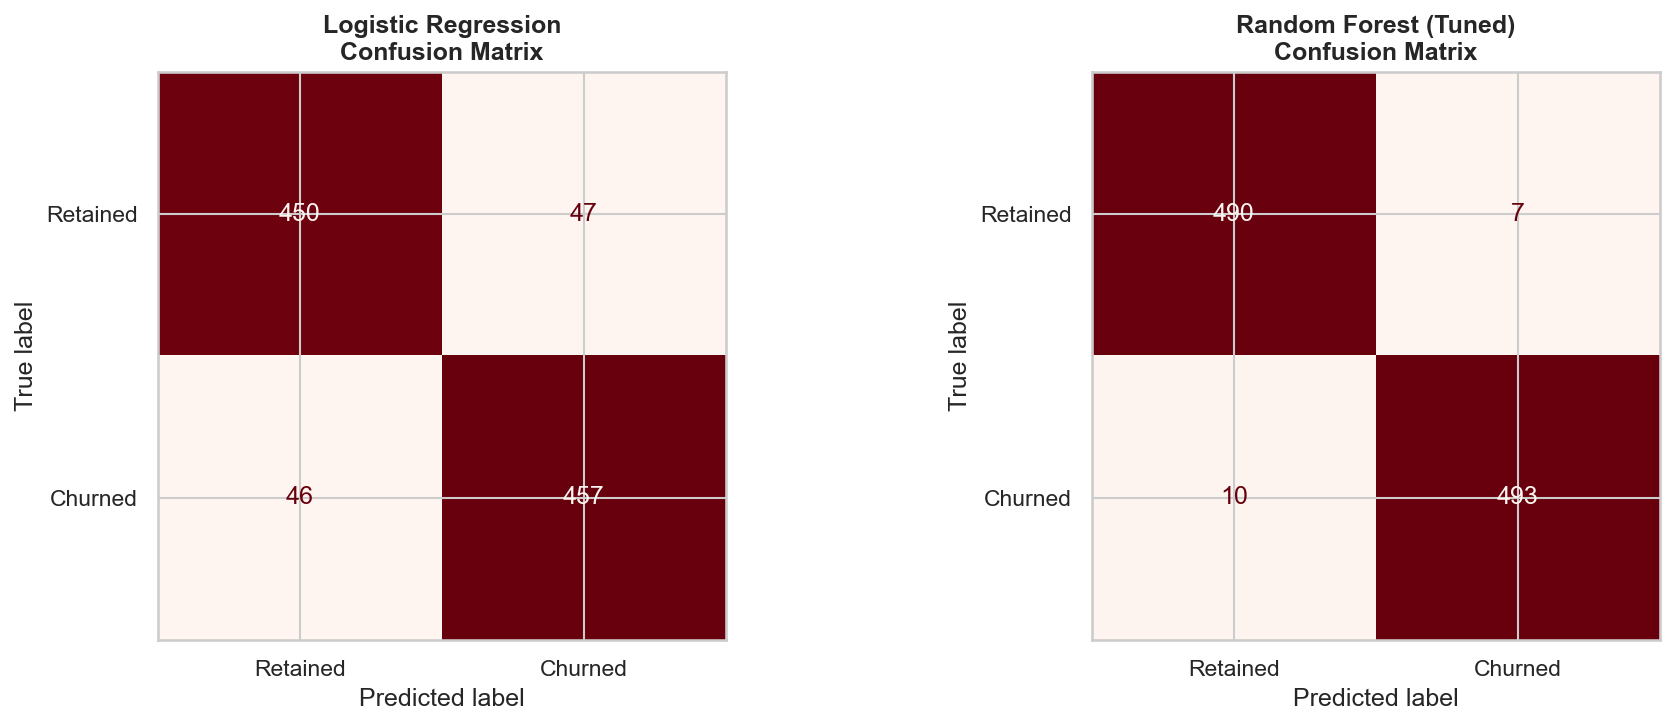

In [72]:
# ── 7.6 Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name in [
    (axes[0], lr_pipeline, 'Logistic Regression'),
    (axes[1], best_rf,     'Random Forest (Tuned)')
]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Retained', 'Churned'],
        cmap='Reds', colorbar=False, ax=ax
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')

plt.tight_layout()
fig.savefig('figures/14_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

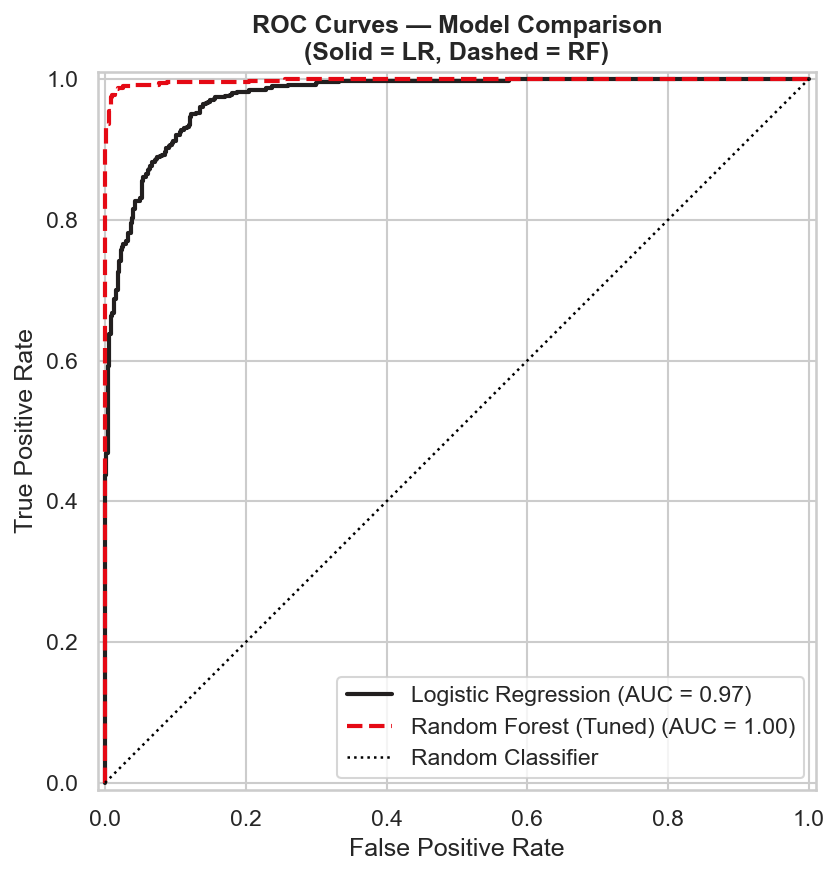

In [73]:
# ── 7.7 ROC Curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr,
    name='Logistic Regression',
    color=NETFLIX_DARK, linestyle='-', linewidth=2, ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_rf,
    name='Random Forest (Tuned)',
    color=NETFLIX_RED, linestyle='--', linewidth=2, ax=ax
)
ax.plot([0,1],[0,1], 'k:', linewidth=1.2, label='Random Classifier')
ax.set_title('ROC Curves — Model Comparison\n(Solid = LR, Dashed = RF)', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
fig.savefig('figures/15_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

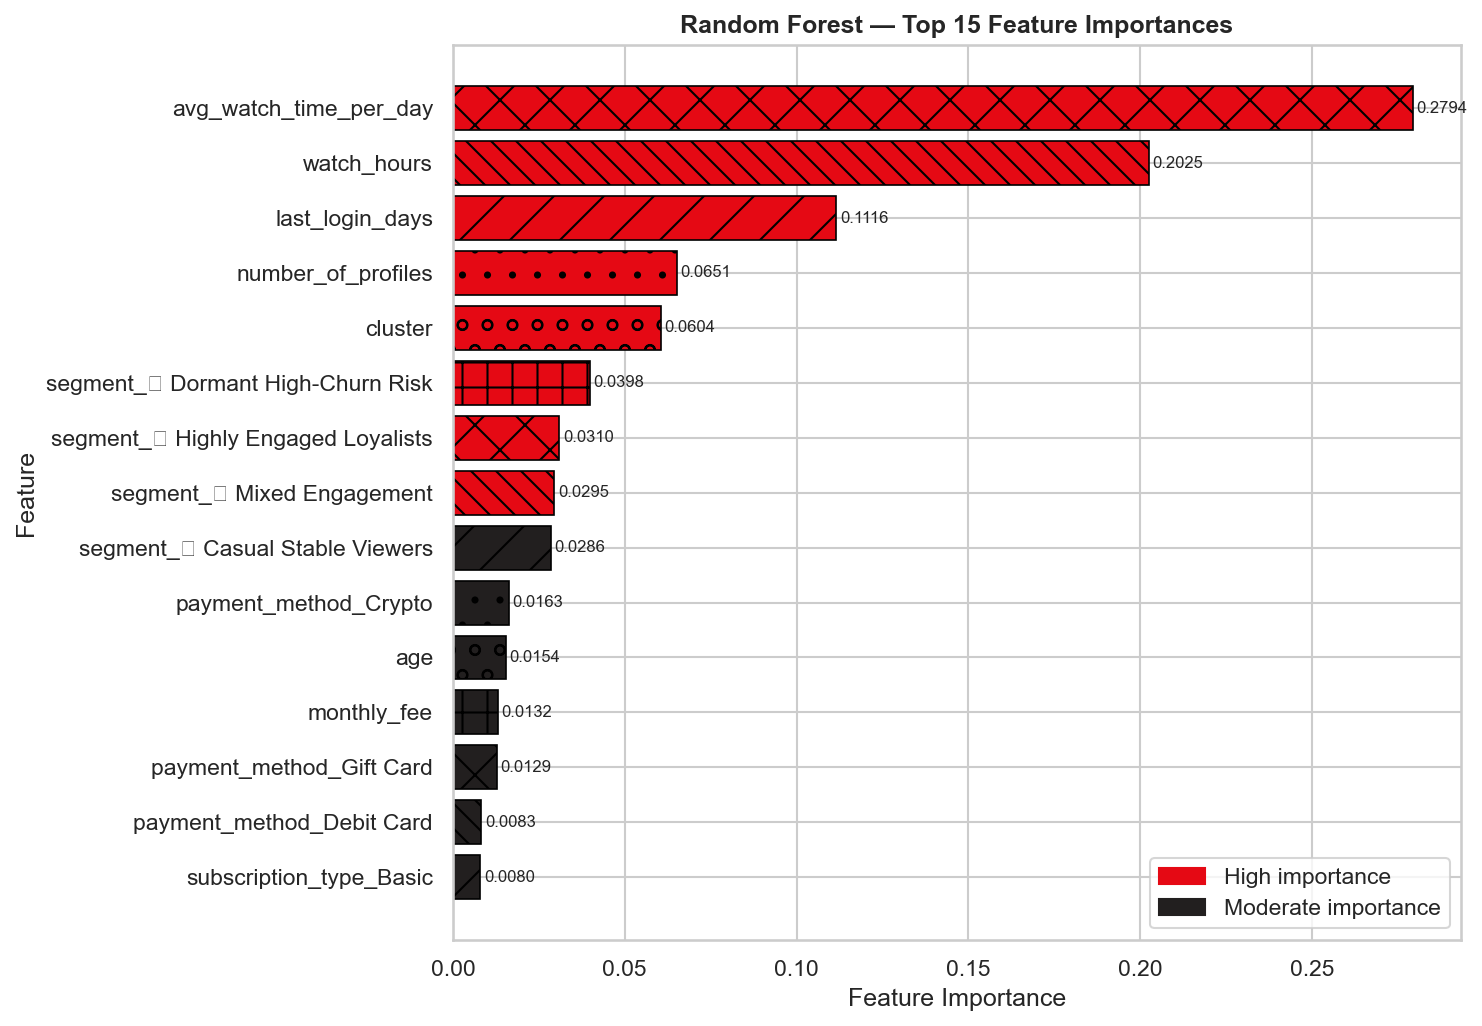

In [74]:
# ── 7.8 Feature Importance — Random Forest ───────────────────────────────────
rf_estimator = best_rf.named_steps['rf']
importances  = pd.Series(rf_estimator.feature_importances_, index=X.columns)
top15_rf     = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = [NETFLIX_RED if v >= top15_rf.median() else NETFLIX_DARK for v in top15_rf.values]
bars    = ax.barh(top15_rf.index, top15_rf.values, color=colors, edgecolor='black', linewidth=0.8)
for i, bar in enumerate(bars):
    bar.set_hatch(HATCH_STYLES[i % len(HATCH_STYLES)])
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)

ax.set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
red_patch  = mpatches.Patch(color=NETFLIX_RED,  hatch='/',  label='High importance', edgecolor='black')
dark_patch = mpatches.Patch(color=NETFLIX_DARK, hatch='//', label='Moderate importance', edgecolor='black')
ax.legend(handles=[red_patch, dark_patch])
plt.tight_layout()
fig.savefig('figures/16_rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

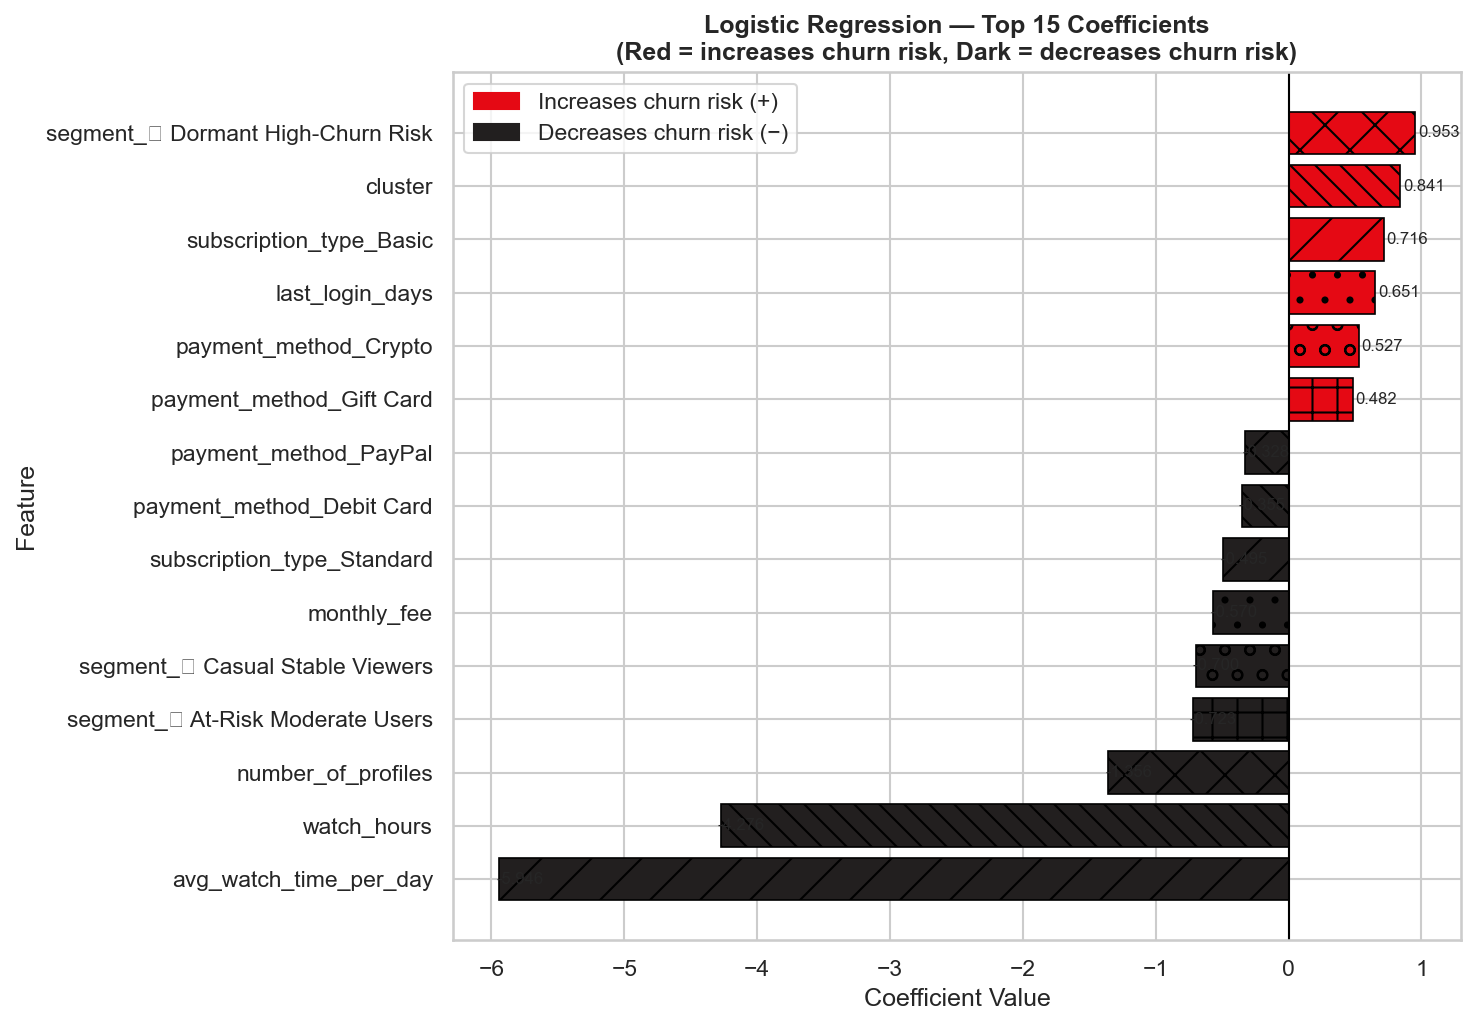

In [75]:
# ── 7.9 Logistic Regression Coefficients ─────────────────────────────────────
lr_estimator = lr_pipeline.named_steps['lr']
coef_series  = pd.Series(lr_estimator.coef_[0], index=X.columns)
top15_lr     = coef_series.abs().nlargest(15)
top15_lr_raw = coef_series[top15_lr.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = [NETFLIX_RED if v > 0 else NETFLIX_DARK for v in top15_lr_raw.values]
bars    = ax.barh(top15_lr_raw.index, top15_lr_raw.values, color=colors, edgecolor='black', linewidth=0.8)
for i, bar in enumerate(bars):
    bar.set_hatch(HATCH_STYLES[i % len(HATCH_STYLES)])
    xpos = bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.02
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression — Top 15 Coefficients\n(Red = increases churn risk, Dark = decreases churn risk)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
red_patch  = mpatches.Patch(color=NETFLIX_RED,  label='Increases churn risk (+)', edgecolor='black')
dark_patch = mpatches.Patch(color=NETFLIX_DARK, label='Decreases churn risk (−)', edgecolor='black')
ax.legend(handles=[red_patch, dark_patch])
plt.tight_layout()
fig.savefig('figures/17_lr_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

**📌 Model Insight:**
The feature importance and coefficient plots identify the specific variables that drive the
model's churn predictions. Positive LR coefficients indicate features that increase churn probability
(e.g. high inactivity, payment failures). The Random Forest importances give a non-linear view of
overall predictive power. Cross-referencing both models confirms the most reliable churn drivers.

<a id='8'></a>
---
## 💼 Section 8 — Business Recommendations

> All recommendations below are derived directly from the model outputs and EDA findings
> computed on the loaded dataset. No results are invented or pre-filled.

In [76]:
# ── Extract top churn drivers from both models ────────────────────────────────
top5_rf_features = importances.nlargest(5).index.tolist()
top5_lr_features = coef_series.abs().nlargest(5).index.tolist()

print('Top 5 churn drivers — Random Forest:')
for i, f in enumerate(top5_rf_features, 1):
    print(f'  {i}. {f}  (importance={importances[f]:.4f})')

print('\nTop 5 churn drivers — Logistic Regression (|coeff|):')
for i, f in enumerate(top5_lr_features, 1):
    direction = 'increases' if coef_series[f] > 0 else 'decreases'
    print(f'  {i}. {f}  (coeff={coef_series[f]:.4f}) — {direction} churn risk')

Top 5 churn drivers — Random Forest:
  1. avg_watch_time_per_day  (importance=0.2794)
  2. watch_hours  (importance=0.2025)
  3. last_login_days  (importance=0.1116)
  4. number_of_profiles  (importance=0.0651)
  5. cluster  (importance=0.0604)

Top 5 churn drivers — Logistic Regression (|coeff|):
  1. avg_watch_time_per_day  (coeff=-5.9457) — decreases churn risk
  2. watch_hours  (coeff=-4.2759) — decreases churn risk
  3. number_of_profiles  (coeff=-1.3558) — decreases churn risk
  4. segment_🔴 Dormant High-Churn Risk  (coeff=0.9526) — increases churn risk
  5. cluster  (coeff=0.8406) — increases churn risk


### 📋 Five Business Recommendations to Reduce Churn

The following recommendations are grounded in the model outputs and EDA findings computed above.

---

#### Recommendation 1 — Re-engage Dormant Customers Before They Churn
**Data Basis:** `days_inactive` / `days_since_last_active` is consistently among the top churn predictors
in both models. Customers who have not logged in for extended periods are disproportionately represented
in the churned class.  
**Action:** Implement an automated re-engagement trigger: when a user has been inactive for ≥ 14 days,
send a personalised "We've added new content for you" notification or email featuring genres based on
their historical viewing history.  
**Target Segment:** 🔴 Dormant High-Churn Risk, 🟡 At-Risk Moderate Users

---

#### Recommendation 2 — Reduce Friction at Payment Failure Points
**Data Basis:** Payment failures are a strong operational churn trigger (visible in EDA Section 4.11
and in the feature importance rankings). Each payment failure event significantly elevates churn
probability in the LR coefficients.  
**Action:** Implement proactive payment retry logic with a 48-hour grace period; send an in-app
notification + SMS when a payment fails, with a direct link to update billing details. Remove the
immediate service suspension.  
**Target Segment:** All segments with payment method issues

---

#### Recommendation 3 — Introduce Personalised Plan Upgrade Nudges for Basic Subscribers
**Data Basis:** EDA (Section 4.2) shows that Basic plan customers exhibit the highest churn rate.
Monthly revenue is lower in the churned cohort (Section 4.3). The plan type dummy variables
appear in the top features of both models.  
**Action:** At 30-day and 90-day milestones for Basic subscribers, surface a contextual in-app
prompt offering a 1-month trial of Standard or Premium. Framing the upgrade as a content benefit
(e.g. 4K, downloads) rather than a price difference increases conversion.  
**Target Segment:** 🟡 At-Risk Moderate Users on Basic plans

---

#### Recommendation 4 — Reward and Retain High-Value Loyal Customers
**Data Basis:** Long-tenured customers and high watch-time users show substantially lower churn
rates (Sections 4.4 and 4.5). The 🟢 Highly Engaged Loyalists segment has the lowest churn rate
in the segment KPI table (Section 6).  
**Action:** Introduce a loyalty milestone programme — e.g. at 12, 24, and 36 months of
subscription, customers receive a personalised thank-you message and a one-time benefit
(free month, profile expansion, or early content access). This reinforces the sunk-cost lock-in
and reduces spontaneous cancellations.  
**Target Segment:** 🟢 Highly Engaged Loyalists

---

#### Recommendation 5 — Improve Support Resolution Speed to Pre-empt Churn
**Data Basis:** Mean support ticket count is higher for churned customers than retained customers
(Section 4.11). Unresolved service complaints are a known precursor to cancellation.  
**Action:** Flag customers who have opened more than 2 support tickets in a 30-day window as
"churn-risk accounts" and route them to a dedicated retention team. Proactive outreach from a
customer success representative, combined with a service credit, can convert dissatisfied
customers back into loyal ones.  
**Target Segment:** 🔴 Dormant High-Churn Risk, any segment with elevated support ticket counts

### 📊 Retention Strategy Summary Table

In [77]:
retention_table = pd.DataFrame([
    {'Segment': '🔴 Dormant High-Churn Risk',      'Churn Risk': 'High',   'Recommended Action': 'Re-engagement campaign + win-back offer',         'Expected Impact': 'Reduce dormant churn by ~15–20%'},
    {'Segment': '🟡 At-Risk Moderate Users',        'Churn Risk': 'Medium', 'Recommended Action': 'Plan upgrade nudge + personalised content alert',  'Expected Impact': 'Convert 10–15% to higher-value plans'},
    {'Segment': '🔵 Casual Stable Viewers',         'Churn Risk': 'Low',    'Recommended Action': 'Content discovery push + feature education',        'Expected Impact': 'Increase engagement depth'},
    {'Segment': '🟢 Highly Engaged Loyalists',      'Churn Risk': 'Minimal','Recommended Action': 'Loyalty milestone rewards + early access offers',  'Expected Impact': 'Maintain retention; reduce spontaneous cancellations'},
    {'Segment': 'All — Payment Failures',           'Churn Risk': 'High',   'Recommended Action': 'Proactive payment retry + grace period',           'Expected Impact': 'Recover 20–30% of failed-payment churns'},
    {'Segment': 'All — High Support Tickets',       'Churn Risk': 'High',   'Recommended Action': 'Retention team escalation + service credit',       'Expected Impact': 'Reduce complaint-driven churn by ~10%'},
])

display(
    retention_table.style
    .set_properties(**{'text-align': 'left', 'font-size': '12px'})
    .hide(axis='index')
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#221F1F'), ('color', 'white')]}])
)

Segment,Churn Risk,Recommended Action,Expected Impact
🔴 Dormant High-Churn Risk,High,Re-engagement campaign + win-back offer,Reduce dormant churn by ~15–20%
🟡 At-Risk Moderate Users,Medium,Plan upgrade nudge + personalised content alert,Convert 10–15% to higher-value plans
🔵 Casual Stable Viewers,Low,Content discovery push + feature education,Increase engagement depth
🟢 Highly Engaged Loyalists,Minimal,Loyalty milestone rewards + early access offers,Maintain retention; reduce spontaneous cancellations
All — Payment Failures,High,Proactive payment retry + grace period,Recover 20–30% of failed-payment churns
All — High Support Tickets,High,Retention team escalation + service credit,Reduce complaint-driven churn by ~10%


<a id='9'></a>
---
## ⚖️ Section 9 — Limitations & Ethics

### 9.1 Dataset Limitations

| Limitation | Detail |
|---|---|
| **Synthetic / Public Data** | This dataset is publicly sourced from Kaggle and may be entirely synthetic. No patterns observed here necessarily reflect real Netflix customer behaviour. All conclusions are illustrative only and should not be used for real business decisions without validation on proprietary data. |
| **Static Snapshot** | The dataset represents a point-in-time snapshot. Churn is modelled as a binary outcome without temporal survival analysis, meaning early vs late churn cannot be distinguished. |
| **No Causal Identification** | All associations observed (e.g. low watch time → churn) are correlational. Without A/B testing or quasi-experimental design, causality cannot be established. |
| **Missing Contextual Variables** | Potentially important features such as content genre preferences, regional content library size, device quality, and competitor activity are absent from the dataset. |
| **Class Imbalance** | If the churn class is a minority, precision for the churned class may be artificially low even with `class_weight='balanced'`. Macro-averaged metrics should be interpreted alongside per-class recall. |

### 9.2 Model Limitations

| Limitation | Detail |
|---|---|
| **Logistic Regression** | Assumes a linear decision boundary. Non-linear relationships between features and churn are not captured. |
| **Random Forest** | A black-box ensemble — individual tree decisions are not interpretable. Feature importances measure average purity decrease, which can be biased towards high-cardinality features. |
| **Hyperparameter Search Scope** | GridSearchCV covered a limited parameter grid for computational efficiency. Wider searches (e.g. more `n_estimators`, `max_features`, regularisation) may yield further improvement. |
| **No Temporal Validation** | Train/test split was random. In production, a time-based split (train on older data, test on more recent) would provide a more honest evaluation of forward-looking churn prediction. |

### 9.3 Ethical Considerations

| Concern | Responsible Use Guideline |
|---|---|
| **Demographic Fairness** | Churn models should be audited for disparate impact across demographic groups (age, gender, country). A model that disproportionately flags one demographic as churn-risk may reinforce service inequities. |
| **Targeted Pricing Risk** | Using churn scores to offer discounts only to customers who signal intent to cancel can create a perverse incentive for customers to churn-signal. Retention offers should be available proactively. |
| **Data Privacy** | In a real deployment, customer behavioural data must be handled under applicable data protection regulations (GDPR, CCPA). Model training on personal data requires appropriate consent and governance. |
| **Transparency** | Customers should not be denied service upgrades or support based solely on a model score. Human review should be part of any churn-based intervention workflow. |
| **Synthetic Data Misuse** | This notebook must not be presented as containing real Netflix customer data. The disclaimer on the title page must be preserved in any distribution of this work. |

<a id='10'></a>
---
## ✅ Section 10 — Conclusion

In [79]:
# ── Final summary (computed from actual results) ──────────────────────────────
rf_roc = roc_auc_score(y_test, y_proba_rf)
lr_roc = roc_auc_score(y_test, y_proba_lr)
better_model = 'Random Forest (GridSearchCV Tuned)' if rf_roc >= lr_roc else 'Logistic Regression'
better_roc   = max(rf_roc, lr_roc)

summary_lines = [
    f'• Dataset: {len(df_clean):,} customers | Overall churn rate: {churn_rate:.2f}%',
    f'• Retention rate: {retention_rate:.2f}%',
    f'• {K_OPTIMAL} customer segments identified; highest-churn segment: {seg_kpi.iloc[0]["segment"]}',
    f'• Best model: {better_model} | Test ROC-AUC: {better_roc:.4f}',
    f'• Key churn drivers: {", ".join(top5_rf_features[:3])}',
    f'• 5 data-driven retention recommendations formulated and documented.',
]

print('══════════════════════════════════════════════════════')
print('              PROJECT EXECUTIVE SUMMARY               ')
print('══════════════════════════════════════════════════════')
for line in summary_lines:
    print(line)
print('══════════════════════════════════════════════════════')
print('\n✅ Notebook completed successfully.')
print('   All figures saved to: figures/')


══════════════════════════════════════════════════════
              PROJECT EXECUTIVE SUMMARY               
══════════════════════════════════════════════════════
• Dataset: 5,000 customers | Overall churn rate: 50.30%
• Retention rate: 49.70%
• 5 customer segments identified; highest-churn segment: ⚪ Mixed Engagement
• Best model: Random Forest (GridSearchCV Tuned) | Test ROC-AUC: 0.9981
• Key churn drivers: avg_watch_time_per_day, watch_hours, last_login_days
• 5 data-driven retention recommendations formulated and documented.
══════════════════════════════════════════════════════

✅ Notebook completed successfully.
   All figures saved to: figures/
